In [3]:
"""
完全版：直近データ取得 + 現在効いているファクター分析
- J-Quants API v2で最新データ自動取得
- FF5ファクター計算
- 最新月の支配的ファクター特定
- 投資戦略提案

使用方法:
    python analyze_current_factors_complete.py

必要な環境変数:
    JQUANTS_API_KEY: J-Quants APIキー（.envファイルまたは環境変数）
"""

import os
import requests
import time
from typing import Optional, List, Dict
import pandas as pd
import numpy as np
from pathlib import Path
from dotenv import load_dotenv
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("完全版：直近データ取得 + 現在効いているファクター分析")
print("="*80)

# ========================================
# 環境設定
# ========================================

# 環境変数読み込み
env_path = Path(r"C:\Users\yongr\Project\J-Quants.env")
if env_path.exists():
    load_dotenv(env_path, override=True)
    print(f"✅ 環境変数読み込み: {env_path}")
else:
    print(f"⚠️ .envファイル未検出（環境変数から読み込み）")

# ディレクトリ設定
OUTPUT_DIR = Path(r"C:\Users\yongr\Project\merged_data_all_stocks")
FACTORS_DIR = OUTPUT_DIR / "factors"
DATA_DIR = OUTPUT_DIR / "jquants_data"

# ディレクトリ作成
FACTORS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

SNAP_PATH = FACTORS_DIR / "month_end_snapshot.parquet"

# ========================================
# APIクライアント
# ========================================

class JQuantsAPIV2:
    """J-Quants API v2クライアント"""
    
    def __init__(self, api_key: Optional[str] = None, plan: str = "Standard", timeout_sec: int = 60):
        self.base_url = "https://api.jquants.com/v2"
        self.api_key = api_key or os.getenv("JQUANTS_API_KEY")
        
        if not self.api_key:
            raise ValueError("環境変数 'JQUANTS_API_KEY' が見つかりません。")
        
        self.timeout_sec = timeout_sec
        self.session = requests.Session()
        
        # プラン別のレート制限
        delay_map = {"Free": 12.0, "Light": 1.0, "Standard": 0.5, "Premium": 0.12}
        self.delay_sec = delay_map.get(plan, 0.5)
        
        print(f"✅ APIクライアント初期化（プラン: {plan}）")

    def _headers(self) -> Dict[str, str]:
        return {"x-api-key": self.api_key}
    
    def _safe_request(self, method: str, url: str, params: Optional[Dict] = None, max_retries: int = 3) -> Dict:
        """リトライ機能付きリクエスト"""
        for attempt in range(max_retries):
            try:
                r = self.session.get(url, headers=self._headers(), params=params or {}, timeout=self.timeout_sec)
                r.raise_for_status()
                time.sleep(self.delay_sec)
                return r.json()
            except requests.exceptions.HTTPError as e:
                if e.response.status_code == 429:
                    wait_time = self.delay_sec * (2 ** attempt)
                    print(f"  ⚠️ レート制限。{wait_time:.1f}秒待機...")
                    time.sleep(wait_time)
                else:
                    raise
        raise Exception(f"最大リトライ回数超過: {url}")

    def get_trading_calendar(self, from_date: str = None, to_date: str = None) -> List[Dict]:
        """取引カレンダー取得"""
        url = f"{self.base_url}/markets/calendar"
        params = {}
        if from_date:
            params['from'] = from_date
        if to_date:
            params['to'] = to_date
        return self._safe_request("GET", url, params).get("data", [])

    def get_latest_trading_day(self) -> str:
        """最新営業日取得"""
        to_date = datetime.now().strftime('%Y-%m-%d')
        from_date = (datetime.now() - timedelta(days=30)).strftime('%Y-%m-%d')
        
        calendar = self.get_trading_calendar(from_date=from_date, to_date=to_date)
        if not calendar:
            return to_date
        
        trading_days = [d['Date'] for d in calendar if d.get('HolidayDivision') == '0']
        return max(trading_days) if trading_days else to_date

    def get_daily_bars(self, date: str) -> List[Dict]:
        """日次株価データ取得"""
        url = f"{self.base_url}/equities/bars/daily"
        params = {'date': date}
        return self._safe_request("GET", url, params).get("data", [])

    def batch_download_daily_bars(self, start_date: str, end_date: str) -> pd.DataFrame:
        """期間指定で日次データ一括取得"""
        print(f"\n📥 日次データ取得: {start_date} 〜 {end_date}")
        
        calendar = self.get_trading_calendar(from_date=start_date, to_date=end_date)
        trading_days = [d['Date'] for d in calendar if d.get('HolidayDivision') == '0']
        
        if len(trading_days) == 0:
            print("  ⚠️ 対象営業日なし")
            return pd.DataFrame()
        
        print(f"  営業日数: {len(trading_days)}日")
        
        all_data = []
        for i, date in enumerate(trading_days, 1):
            print(f"  {i}/{len(trading_days)}: {date}", end="\r")
            data = self.get_daily_bars(date)
            all_data.extend(data)
        
        print(f"\n  ✅ 取得完了: {len(all_data):,}行")
        return pd.DataFrame(all_data)

# ========================================
# ステップ1: データ更新（差分取得）
# ========================================

print("\n" + "="*80)
print("【ステップ1】データ更新（差分取得）")
print("="*80)

# APIクライアント初期化
try:
    api = JQuantsAPIV2(plan="Standard")
except ValueError as e:
    print(f"❌ {e}")
    print("\n⚠️ J-Quants APIキーを設定してください")
    print("   1. https://application.jpx-jquants.com/ でAPIキー取得")
    print("   2. 環境変数 JQUANTS_API_KEY に設定")
    print("   3. または .env ファイルに記載")
    exit(1)

# 既存データの確認
if SNAP_PATH.exists():
    snap_existing = pd.read_parquet(SNAP_PATH, engine="pyarrow")
    snap_existing['MonthEnd'] = pd.to_datetime(snap_existing['MonthEnd'])
    snap_existing['MonthEnd'] = snap_existing['MonthEnd'].dt.to_period('M').dt.to_timestamp('M')
    
    if 'Date' in snap_existing.columns:
        snap_existing['Date'] = pd.to_datetime(snap_existing['Date'])
        last_date = snap_existing['Date'].max()
    else:
        last_date = snap_existing['MonthEnd'].max()
    
    print(f"✅ 既存データ検出")
    print(f"   最終日: {last_date.date()}")
    print(f"   銘柄数: {snap_existing['Code'].nunique()}")
    print(f"   月数: {snap_existing['MonthEnd'].nunique()}ヶ月")
else:
    snap_existing = pd.DataFrame()
    last_date = pd.Timestamp('2015-01-01')
    print(f"⚠️ 既存データなし → {last_date.date()}から取得")

# 最新営業日取得
latest_day = api.get_latest_trading_day()
print(f"✅ 最新営業日: {latest_day}")

# 差分取得判定
start_date = (last_date + timedelta(days=1)).strftime('%Y-%m-%d')
end_date = latest_day

if start_date > end_date:
    print(f"\n✅ データは最新です（更新不要）")
    snap = snap_existing
else:
    print(f"\n📥 差分期間: {start_date} 〜 {end_date}")
    
    df_new_daily = api.batch_download_daily_bars(start_date, end_date)
    
    if len(df_new_daily) > 0:
        df_new_daily['Date'] = pd.to_datetime(df_new_daily['Date'])
        df_new_daily['MonthEnd'] = df_new_daily['Date'].dt.to_period('M').dt.to_timestamp('M')
        
        # 列名統一
        if 'AdjustmentClose' in df_new_daily.columns:
            df_new_daily = df_new_daily.rename(columns={'AdjustmentClose': 'AdjustedClose'})
        
        # 月末データ抽出
        df_new_monthly = df_new_daily.groupby(['Code', 'MonthEnd']).last().reset_index()
        
        # 既存データと統合
        if len(snap_existing) > 0:
            common_cols = list(set(snap_existing.columns) & set(df_new_monthly.columns))
            df_combined = pd.concat([
                snap_existing[common_cols],
                df_new_monthly[common_cols]
            ], ignore_index=True)
            df_combined = df_combined.drop_duplicates(subset=['Code', 'MonthEnd'], keep='last')
            df_combined = df_combined.sort_values(['Code', 'MonthEnd'])
        else:
            df_combined = df_new_monthly
        
        snap = df_combined
        
        # 保存
        snap.to_parquet(SNAP_PATH, engine="pyarrow", index=False)
        print(f"✅ データ更新・保存完了: {len(snap):,}行")
    else:
        snap = snap_existing

# ========================================
# ステップ2: FF5ファクター計算（直近3ヶ月）
# ========================================

print("\n" + "="*80)
print("【ステップ2】FF5ファクター計算（直近3ヶ月）")
print("="*80)

snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"], errors="coerce")
snap = snap[snap["MonthEnd"].notna()].copy()
snap["Code"] = snap["Code"].astype(str)

latest_month = snap["MonthEnd"].max()
n_months = snap["MonthEnd"].nunique()
n_stocks = snap["Code"].nunique()

print(f"  期間: {snap['MonthEnd'].min().strftime('%Y-%m')} 〜 {latest_month.strftime('%Y-%m')}")
print(f"  月数: {n_months}ヶ月")
print(f"  銘柄数: {n_stocks}")

# 月次リターン計算
snap = snap.sort_values(["Code","MonthEnd"], kind="mergesort").reset_index(drop=True)
p = pd.to_numeric(snap["AdjustedClose"], errors="coerce")
p_next = pd.to_numeric(snap.groupby("Code")["AdjustedClose"].shift(-1), errors="coerce")
snap["ret_m_fwd"] = (p_next / p - 1.0).astype("float32")
snap["MonthEnd_next"] = snap.groupby("Code")["MonthEnd"].shift(-1)
snap = snap[snap["MonthEnd_next"].notna()].copy()
snap["MonthEnd_next"] = pd.to_datetime(snap["MonthEnd_next"])

# 市場キャップ
snap["MarketCap"] = pd.to_numeric(snap["MarketCap"], errors="coerce")

def vw_ret(df, ret_col="ret_m_fwd", w_col="MarketCap"):
    """時価総額加重平均リターン"""
    r = pd.to_numeric(df[ret_col], errors="coerce")
    w = pd.to_numeric(df[w_col], errors="coerce")
    m = r.notna() & w.notna() & (w > 0)
    if m.sum() == 0:
        return np.nan
    return float(np.sum(r[m] * w[m]) / np.sum(w[m]))

# 市場ファクター
mkt = snap.groupby("MonthEnd_next", sort=True, group_keys=False).apply(
    lambda x: vw_ret(x), include_groups=False
).reset_index()
mkt.columns = ["MonthEnd", "MKT"]

# 2×3形成関数
def assign_size_group(x, me_col="MarketCap"):
    med = x[me_col].median(skipna=True)
    return np.where(x[me_col] <= med, "S", "B")

def assign_tercile_group(x, col):
    q30 = x[col].quantile(0.3)
    q70 = x[col].quantile(0.7)
    out = np.full(len(x), "N", dtype=object)
    out[x[col] <= q30] = "L"
    out[x[col] >= q70] = "H"
    return out

# 直近3ヶ月のファクター計算
recent_months = sorted(snap["MonthEnd_next"].unique())[-3:]
print(f"\n  対象月: {[m.strftime('%Y-%m') for m in recent_months]}")

records_f = []

for mo in recent_months:
    x = snap[snap["MonthEnd_next"] == mo].copy()
    x["MarketCap"] = pd.to_numeric(x["MarketCap"], errors="coerce")
    x["BM_Ratio"]  = pd.to_numeric(x.get("BM_Ratio"), errors="coerce")
    x["ROE"]       = pd.to_numeric(x.get("ROE"), errors="coerce")
    x["INV_Growth"]= pd.to_numeric(x.get("INV_Growth"), errors="coerce")

    x = x[x["MarketCap"].notna() & (x["MarketCap"] > 0) & x["ret_m_fwd"].notna()].copy()
    if len(x) < 200:
        continue

    x["Size"] = assign_size_group(x, "MarketCap")

    # B/M (HML)
    xb = x[x["BM_Ratio"].notna()].copy()
    if len(xb) > 50:
        xb["BM3"] = assign_tercile_group(xb, "BM_Ratio")
        bm = {}
        for sz in ["S","B"]:
            for g in ["L","N","H"]:
                bm[f"{sz}{g}"] = vw_ret(xb[(xb["Size"]==sz) & (xb["BM3"]==g)])
        HML = 0.5*(bm["SH"]+bm["BH"]) - 0.5*(bm["SL"]+bm["BL"])
        SMB_BM = (bm["SL"]+bm["SN"]+bm["SH"])/3 - (bm["BL"]+bm["BN"]+bm["BH"])/3
    else:
        HML = np.nan; SMB_BM = np.nan

    # ROE (RMW)
    xr = x[x["ROE"].notna()].copy()
    if len(xr) > 50:
        xr["ROE3"] = assign_tercile_group(xr, "ROE")
        roe = {}
        for sz in ["S","B"]:
            for g in ["L","N","H"]:
                roe[f"{sz}{g}"] = vw_ret(xr[(xr["Size"]==sz) & (xr["ROE3"]==g)])
        RMW = 0.5*(roe["SH"]+roe["BH"]) - 0.5*(roe["SL"]+roe["BL"])
        SMB_ROE = (roe["SL"]+roe["SN"]+roe["SH"])/3 - (roe["BL"]+roe["BN"]+roe["BH"])/3
    else:
        RMW = np.nan; SMB_ROE = np.nan

    # INV (CMA)
    xi = x[x["INV_Growth"].notna()].copy()
    if len(xi) > 50:
        xi["INV3"] = assign_tercile_group(xi, "INV_Growth")
        inv = {}
        for sz in ["S","B"]:
            for g in ["L","N","H"]:
                inv[f"{sz}{g}"] = vw_ret(xi[(xi["Size"]==sz) & (xi["INV3"]==g)])
        CMA = 0.5*(inv["SL"]+inv["BL"]) - 0.5*(inv["SH"]+inv["BH"])
        SMB_INV = (inv["SL"]+inv["SN"]+inv["SH"])/3 - (inv["BL"]+inv["BN"]+inv["BH"])/3
    else:
        CMA = np.nan; SMB_INV = np.nan

    SMB = np.nanmean([SMB_BM, SMB_ROE, SMB_INV])

    records_f.append({
        "MonthEnd": pd.Timestamp(mo),
        "SMB": SMB, "HML": HML, "RMW": RMW, "CMA": CMA,
        "n_stocks": int(len(x))
    })

f = pd.DataFrame(records_f).sort_values("MonthEnd").reset_index(drop=True)
ff = f.merge(mkt, on="MonthEnd", how="left")

print(f"  ✅ FF5ファクター計算完了: {len(ff)}ヶ月")

# ========================================
# ステップ3: 直近月の支配的ファクター特定
# ========================================

print("\n" + "="*80)
print("【ステップ3】直近月の支配的ファクター特定")
print("="*80)

if len(ff) == 0:
    print("❌ ファクターデータなし")
    exit(1)

latest = ff.iloc[-1].copy()
factor_cols = ["MKT","SMB","HML","RMW","CMA"]

# 絶対値最大のファクター
vals = latest[factor_cols].astype(float)
abs_vals = vals.abs()
most_influential = abs_vals.idxmax()
max_abs_value = abs_vals.max()

# 結果表示
print(f"\n{'='*80}")
print(f"📊 直近月の値動きを説明するFF5ファクター")
print(f"{'='*80}")

print(f"\n📅 分析対象月: {latest['MonthEnd'].strftime('%Y年%m月')}")
print(f"📊 対象銘柄数: {int(latest['n_stocks'])}銘柄")

print(f"\n【ファクターリターン】")
for col in factor_cols:
    val = latest[col]
    bar_len = int(abs(val) * 200)
    bar = "█" * min(bar_len, 50)
    sign = "+" if val > 0 else ""
    highlight = " ⭐" if col == most_influential else ""
    print(f"  {col:3s}: {sign}{val*100:6.2f}% {bar}{highlight}")

print(f"\n{'='*80}")
print(f"🎯 最も影響力の大きいファクター: {most_influential}")
print(f"   リターン: {vals[most_influential]*100:+.2f}%")
print(f"{'='*80}")

# ファクター解釈
interpretations = {
    "MKT": "市場全体の動き（ベータ効果）が支配的\n   → 銘柄選択よりも市場参加が重要な局面",
    "SMB": "小型株効果が顕著\n   → サイズファクターが市場を牽引" if vals["SMB"] > 0 else "大型株優位\n   → 大型株への資金集中が進んでいる",
    "HML": "バリュー株優位\n   → 割安銘柄への見直しが進行" if vals["HML"] > 0 else "グロース株優位\n   → 成長期待が市場を牽引",
    "RMW": "高収益性銘柄が優位\n   → 質への選好が強まっている" if vals["RMW"] > 0 else "低収益性銘柄が優位\n   → リスクオン・景気敏感株へのローテーション",
    "CMA": "保守的投資銘柄が優位\n   → 慎重な投資スタンスの企業が評価" if vals["CMA"] > 0 else "積極的投資銘柄が優位\n   → 成長投資を進める企業が評価"
}

print(f"\n💡 市場解釈:")
print(f"   {interpretations[most_influential]}")

# ========================================
# ステップ4: 直近3ヶ月のトレンド分析
# ========================================

print(f"\n{'='*80}")
print(f"📈 直近3ヶ月のファクター推移")
print(f"{'='*80}")

if len(ff) >= 3:
    recent_3 = ff.tail(3).copy()
    
    print(f"\n{'月':^10s} {'MKT':>8s} {'SMB':>8s} {'HML':>8s} {'RMW':>8s} {'CMA':>8s} {'支配的':^10s}")
    print("-" * 80)
    
    for _, row in recent_3.iterrows():
        month_str = row['MonthEnd'].strftime('%Y-%m')
        vals_row = row[factor_cols].astype(float)
        abs_vals_row = vals_row.abs()
        dominant = abs_vals_row.idxmax()
        
        print(f"{month_str:^10s} ", end="")
        for col in factor_cols:
            val = row[col]
            print(f"{val*100:+7.2f}% ", end="")
        print(f"{dominant:^10s}")
    
    # トレンド判定
    print(f"\n🔍 トレンド分析:")
    for col in factor_cols:
        trend = recent_3[col].values
        if len(trend) >= 3:
            if trend[-1] > trend[-2] > trend[-3]:
                direction = "📈 上昇トレンド"
            elif trend[-1] < trend[-2] < trend[-3]:
                direction = "📉 下降トレンド"
            else:
                direction = "➡️ 変動的"
            
            avg = trend.mean()
            print(f"  {col}: {direction} (3ヶ月平均: {avg*100:+.2f}%)")

# ========================================
# ステップ5: 投資戦略への示唆
# ========================================

print(f"\n{'='*80}")
print(f"💼 投資戦略への示唆")
print(f"{'='*80}")

latest_mkt = latest['MKT']
latest_smb = latest['SMB']
latest_hml = latest['HML']
latest_rmw = latest['RMW']
latest_cma = latest['CMA']

# 市場環境判定
if abs(latest_mkt) > 0.03:  # 3%以上の市場変動
    if latest_mkt > 0:
        print("\n🟢 強気相場:")
        print("   ✅ インデックス投資が有効")
        print("   ✅ ベータの高い銘柄が有利")
    else:
        print("\n🔴 弱気相場:")
        print("   ⚠️ 防御的ポジション検討")
        print("   ⚠️ 現金比率の引き上げ")
else:
    print("\n⚪ レンジ相場:")
    print("   💡 ファクター選択が重要")

# ファクター戦略
print("\n📊 推奨ファクター露出:")

if latest_rmw > 0.01:
    print("   ✅ 高ROE銘柄（収益性重視）")
elif latest_rmw < -0.01:
    print("   ⚠️ 高ROE銘柄は慎重に")

if latest_hml > 0.01:
    print("   ✅ 高B/M銘柄（バリュー戦略）")
elif latest_hml < -0.01:
    print("   ✅ 低B/M銘柄（グロース戦略）")

if latest_smb > 0.01:
    print("   ✅ 小型株バイアス")
elif latest_smb < -0.01:
    print("   ✅ 大型株重視")

if latest_cma > 0.01:
    print("   ✅ 保守的投資銘柄（低INV_Growth）")
elif latest_cma < -0.01:
    print("   ✅ 積極的投資銘柄（高INV_Growth）")

# ========================================
# ステップ6: 保存
# ========================================

print(f"\n{'='*80}")
print(f"💾 結果保存")
print(f"{'='*80}")

output_path = FACTORS_DIR / "current_factor_analysis.csv"

analysis_result = pd.DataFrame([{
    'AnalysisDate': pd.Timestamp.now(),
    'TargetMonth': latest['MonthEnd'],
    'MKT': latest['MKT'],
    'SMB': latest['SMB'],
    'HML': latest['HML'],
    'RMW': latest['RMW'],
    'CMA': latest['CMA'],
    'MostInfluential': most_influential,
    'MaxAbsValue': max_abs_value,
    'NumStocks': int(latest['n_stocks'])
}])

analysis_result.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"✅ 分析結果保存: {output_path}")

# 直近3ヶ月データも保存
recent_path = FACTORS_DIR / "recent_3months_factors.csv"
if len(ff) >= 3:
    ff.tail(3).to_csv(recent_path, index=False, encoding='utf-8-sig')
    print(f"✅ 直近3ヶ月データ保存: {recent_path}")

# 全期間ファクターデータ保存
all_factors_path = FACTORS_DIR / "ff5_factors_monthly.parquet"
if len(ff) > 0:
    ff.to_parquet(all_factors_path, engine="pyarrow", index=False)
    print(f"✅ 全期間ファクターデータ保存: {all_factors_path}")

print(f"\n{'='*80}")
print(f"✅ 分析完了！")
print(f"{'='*80}")

print(f"\n📁 出力ファイル:")
print(f"  1. {output_path}")
print(f"  2. {recent_path}")
print(f"  3. {all_factors_path}")
print(f"  4. {SNAP_PATH}")


完全版：直近データ取得 + 現在効いているファクター分析
✅ 環境変数読み込み: C:\Users\yongr\Project\J-Quants.env

【ステップ1】データ更新（差分取得）
✅ APIクライアント初期化（プラン: Standard）
✅ 既存データ検出
   最終日: 2026-01-22
   銘柄数: 767
   月数: 121ヶ月
✅ 最新営業日: 2026-01-23

📥 差分期間: 2026-01-23 〜 2026-01-23

📥 日次データ取得: 2026-01-23 〜 2026-01-23
  ⚠️ 対象営業日なし

【ステップ2】FF5ファクター計算（直近3ヶ月）
  期間: 2016-01 〜 2026-01
  月数: 121ヶ月
  銘柄数: 768

  対象月: ['2025-11', '2025-12', '2026-01']
  ✅ FF5ファクター計算完了: 3ヶ月

【ステップ3】直近月の支配的ファクター特定

📊 直近月の値動きを説明するFF5ファクター

📅 分析対象月: 2026年01月
📊 対象銘柄数: 3597銘柄

【ファクターリターン】
  MKT: +198.02% ██████████████████████████████████████████████████
  SMB: +212.58% ██████████████████████████████████████████████████ ⭐
  HML: -193.72% ██████████████████████████████████████████████████
  RMW: + 33.57% ██████████████████████████████████████████████████
  CMA: -49.95% ██████████████████████████████████████████████████

🎯 最も影響力の大きいファクター: SMB
   リターン: +212.58%

💡 市場解釈:
   小型株効果が顕著
   → サイズファクターが市場を牽引

📈 直近3ヶ月のファクター推移

    月           MKT      SMB      HML      RMW   

In [7]:
"""
抜本的改善版：FF5ファクター戦略 - モメンタム統合版

修正点:
1. ファクターモメンタム導入（3ヶ月平均でトレンド判定）
2. ストップロス廃止 → バイ&ホールド重視
3. 半年リバランス → 売買コスト削減
4. 保守的ポジショニング（現金30%保持）
"""

import os
import requests
import time
from typing import Optional, List, Dict
import pandas as pd
import numpy as np
from pathlib import Path
from dotenv import load_dotenv
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("抜本的改善版：FF5ファクター戦略 - モメンタム統合版")
print("="*80)

# ========================================
# 環境設定
# ========================================

env_path = Path(r"C:\Users\yongr\Project\J-Quants.env")
if env_path.exists():
    load_dotenv(env_path, override=True)
    print(f"✅ 環境変数読み込み: {env_path}")

OUTPUT_DIR = Path(r"C:\Users\yongr\Project\merged_data_all_stocks")
BACKTEST_DIR = OUTPUT_DIR / "backtest"
FACTORS_DIR = OUTPUT_DIR / "factors"

BACKTEST_DIR.mkdir(parents=True, exist_ok=True)
FACTORS_DIR.mkdir(parents=True, exist_ok=True)

SNAP_PATH = FACTORS_DIR / "month_end_snapshot.parquet"

# 🆕 改善パラメータ
BACKTEST_YEARS = 10
TARGET_STOCKS = 20
MIN_PRICE = 800
TURNOVER_PERCENTILE = 0.70
INITIAL_CAPITAL = 10_000_000
TRANSACTION_COST = 0.001
REBALANCE_MONTHS = 6  # 🆕 半年ごとにリバランス
CASH_RESERVE_PCT = 0.30  # 🆕 30%現金保持
MOMENTUM_WINDOW = 3  # 🆕 3ヶ月モメンタム

# ========================================
# APIクライアント（省略：前回と同じ）
# ========================================

class JQuantsAPIV2:
    def __init__(self, api_key: Optional[str] = None, plan: str = "Standard", timeout_sec: int = 60):
        self.base_url = "https://api.jquants.com/v2"
        self.api_key = api_key or os.getenv("JQUANTS_API_KEY")
        if not self.api_key:
            raise ValueError("環境変数 'JQUANTS_API_KEY' が見つかりません。")
        self.timeout_sec = timeout_sec
        self.session = requests.Session()
        delay_map = {"Free": 12.0, "Light": 1.0, "Standard": 0.5, "Premium": 0.12}
        self.delay_sec = delay_map.get(plan, 0.5)
        print(f"✅ APIクライアント初期化（プラン: {plan}）")

    def _headers(self) -> Dict[str, str]:
        return {"x-api-key": self.api_key}
    
    def _safe_request(self, method: str, url: str, params: Optional[Dict] = None, max_retries: int = 3) -> Dict:
        for attempt in range(max_retries):
            try:
                r = self.session.get(url, headers=self._headers(), params=params or {}, timeout=self.timeout_sec)
                r.raise_for_status()
                time.sleep(self.delay_sec)
                return r.json()
            except requests.exceptions.HTTPError as e:
                if e.response.status_code == 429:
                    wait_time = self.delay_sec * (2 ** attempt)
                    print(f"  ⚠️ レート制限。{wait_time:.1f}秒待機...")
                    time.sleep(wait_time)
                else:
                    raise
        raise Exception(f"最大リトライ回数超過: {url}")

    def get_trading_calendar(self, from_date: str = None, to_date: str = None) -> List[Dict]:
        url = f"{self.base_url}/markets/calendar"
        params = {}
        if from_date:
            params['from'] = from_date
        if to_date:
            params['to'] = to_date
        return self._safe_request("GET", url, params).get("data", [])

    def get_daily_bars(self, date: str) -> List[Dict]:
        url = f"{self.base_url}/equities/bars/daily"
        params = {'date': date}
        return self._safe_request("GET", url, params).get("data", [])

    def batch_download_daily_bars(self, start_date: str, end_date: str) -> pd.DataFrame:
        print(f"\n📥 日次データ取得: {start_date} 〜 {end_date}")
        calendar = self.get_trading_calendar(from_date=start_date, to_date=end_date)
        trading_days = [d['Date'] for d in calendar if d.get('HolidayDivision') == '0']
        if len(trading_days) == 0:
            return pd.DataFrame()
        print(f"  営業日数: {len(trading_days)}日")
        all_data = []
        for i, date in enumerate(trading_days, 1):
            print(f"  {i}/{len(trading_days)}: {date}", end="\r")
            data = self.get_daily_bars(date)
            all_data.extend(data)
        print(f"\n  ✅ 取得完了: {len(all_data):,}行")
        return pd.DataFrame(all_data)

    def get_listed_info(self) -> List[Dict]:
        url = f"{self.base_url}/equities/master"
        return self._safe_request("GET", url, {}).get("data", [])

# ========================================
# データ準備（省略：前回と同じ）
# ========================================

print("\n" + "="*80)
print("【ステップ1】データ準備")
print("="*80)

try:
    api = JQuantsAPIV2(plan="Standard")
except ValueError as e:
    print(f"❌ {e}")
    exit(1)

snap = pd.read_parquet(SNAP_PATH, engine="pyarrow")
snap['MonthEnd'] = pd.to_datetime(snap['MonthEnd'])
snap['Code'] = snap['Code'].astype(str)

if 'AdjustmentClose' in snap.columns and 'AdjustedClose' not in snap.columns:
    snap = snap.rename(columns={'AdjustmentClose': 'AdjustedClose'})

print(f"✅ 既存データ読み込み: {len(snap):,}行")

df_listed = pd.DataFrame(api.get_listed_info())
print(f"✅ 上場銘柄情報: {len(df_listed)}銘柄")

# ========================================
# FF5ファクター計算（省略：前回と同じ）
# ========================================

print("\n" + "="*80)
print("【ステップ2】FF5ファクター計算")
print("="*80)

snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"], errors="coerce")
snap = snap[snap["MonthEnd"].notna()].copy()
snap["Code"] = snap["Code"].astype(str)

snap = snap.sort_values(["Code","MonthEnd"], kind="mergesort").reset_index(drop=True)
p = pd.to_numeric(snap["AdjustedClose"], errors="coerce")
p_next = pd.to_numeric(snap.groupby("Code")["AdjustedClose"].shift(-1), errors="coerce")
snap["ret_m_fwd"] = (p_next / p - 1.0).astype("float32")
snap["MonthEnd_next"] = snap.groupby("Code")["MonthEnd"].shift(-1)
snap = snap[snap["MonthEnd_next"].notna()].copy()
snap["MonthEnd_next"] = pd.to_datetime(snap["MonthEnd_next"])

snap["MarketCap"] = pd.to_numeric(snap["MarketCap"], errors="coerce")

def vw_ret(df, ret_col="ret_m_fwd", w_col="MarketCap"):
    r = pd.to_numeric(df[ret_col], errors="coerce")
    w = pd.to_numeric(df[w_col], errors="coerce")
    m = r.notna() & w.notna() & (w > 0)
    if m.sum() == 0:
        return np.nan
    return float(np.sum(r[m] * w[m]) / np.sum(w[m]))

mkt = snap.groupby("MonthEnd_next", sort=True, group_keys=False).apply(
    lambda x: vw_ret(x), include_groups=False
).reset_index()
mkt.columns = ["MonthEnd", "MKT"]

def assign_size_group(x, me_col="MarketCap"):
    med = x[me_col].median(skipna=True)
    return np.where(x[me_col] <= med, "S", "B")

def assign_tercile_group(x, col):
    q30 = x[col].quantile(0.3)
    q70 = x[col].quantile(0.7)
    out = np.full(len(x), "N", dtype=object)
    out[x[col] <= q30] = "L"
    out[x[col] >= q70] = "H"
    return out

all_months = sorted(snap["MonthEnd_next"].unique())
print(f"  対象月数: {len(all_months)}ヶ月")

records_f = []

for i, mo in enumerate(all_months, 1):
    if i % 12 == 0:
        print(f"  進捗: {i}/{len(all_months)}ヶ月", end="\r")
    
    x = snap[snap["MonthEnd_next"] == mo].copy()
    x["MarketCap"] = pd.to_numeric(x["MarketCap"], errors="coerce")
    x["BM_Ratio"]  = pd.to_numeric(x.get("BM_Ratio"), errors="coerce")
    x["ROE"]       = pd.to_numeric(x.get("ROE"), errors="coerce")
    x["INV_Growth"]= pd.to_numeric(x.get("INV_Growth"), errors="coerce")

    x = x[x["MarketCap"].notna() & (x["MarketCap"] > 0) & x["ret_m_fwd"].notna()].copy()
    if len(x) < 200:
        continue

    x["Size"] = assign_size_group(x, "MarketCap")

    xb = x[x["BM_Ratio"].notna()].copy()
    if len(xb) > 50:
        xb["BM3"] = assign_tercile_group(xb, "BM_Ratio")
        bm = {}
        for sz in ["S","B"]:
            for g in ["L","N","H"]:
                bm[f"{sz}{g}"] = vw_ret(xb[(xb["Size"]==sz) & (xb["BM3"]==g)])
        HML = 0.5*(bm["SH"]+bm["BH"]) - 0.5*(bm["SL"]+bm["BL"])
        SMB_BM = (bm["SL"]+bm["SN"]+bm["SH"])/3 - (bm["BL"]+bm["BN"]+bm["BH"])/3
    else:
        HML = np.nan; SMB_BM = np.nan

    xr = x[x["ROE"].notna()].copy()
    if len(xr) > 50:
        xr["ROE3"] = assign_tercile_group(xr, "ROE")
        roe = {}
        for sz in ["S","B"]:
            for g in ["L","N","H"]:
                roe[f"{sz}{g}"] = vw_ret(xr[(xr["Size"]==sz) & (xr["ROE3"]==g)])
        RMW = 0.5*(roe["SH"]+roe["BH"]) - 0.5*(roe["SL"]+roe["BL"])
        SMB_ROE = (roe["SL"]+roe["SN"]+roe["SH"])/3 - (roe["BL"]+roe["BN"]+roe["BH"])/3
    else:
        RMW = np.nan; SMB_ROE = np.nan

    xi = x[x["INV_Growth"].notna()].copy()
    if len(xi) > 50:
        xi["INV3"] = assign_tercile_group(xi, "INV_Growth")
        inv = {}
        for sz in ["S","B"]:
            for g in ["L","N","H"]:
                inv[f"{sz}{g}"] = vw_ret(xi[(xi["Size"]==sz) & (xi["INV3"]==g)])
        CMA = 0.5*(inv["SL"]+inv["BL"]) - 0.5*(inv["SH"]+inv["BH"])
        SMB_INV = (inv["SL"]+inv["SN"]+inv["SH"])/3 - (inv["BL"]+inv["BN"]+inv["BH"])/3
    else:
        CMA = np.nan; SMB_INV = np.nan

    SMB = np.nanmean([SMB_BM, SMB_ROE, SMB_INV])

    records_f.append({
        "MonthEnd": pd.Timestamp(mo),
        "SMB": SMB, "HML": HML, "RMW": RMW, "CMA": CMA,
        "n_stocks": int(len(x))
    })

print(f"\n  ✅ ファクター計算完了: {len(records_f)}ヶ月")

f = pd.DataFrame(records_f).sort_values("MonthEnd").reset_index(drop=True)
ff = f.merge(mkt, on="MonthEnd", how="left")

# 🆕 ファクターモメンタム計算
for col in ["MKT", "SMB", "HML", "RMW", "CMA"]:
    ff[f'{col}_momentum'] = ff[col].rolling(MOMENTUM_WINDOW).mean()

# ========================================
# 🆕 バックテスト実行（抜本的改善版）
# ========================================

print("\n" + "="*80)
print("【ステップ3】バックテスト実行（抜本的改善版）")
print("="*80)

end_date = datetime.now()
backtest_start = end_date - timedelta(days=BACKTEST_YEARS*365)
ff_backtest = ff[ff["MonthEnd"] >= pd.Timestamp(backtest_start)].copy()

print(f"\n📊 バックテスト設定:")
print(f"   期間: {ff_backtest['MonthEnd'].min().strftime('%Y-%m')} 〜 {ff_backtest['MonthEnd'].max().strftime('%Y-%m')}")
print(f"   月数: {len(ff_backtest)}ヶ月")
print(f"   初期資金: {INITIAL_CAPITAL:,}円")
print(f"   🆕 リバランス: {REBALANCE_MONTHS}ヶ月ごと")
print(f"   🆕 現金比率: {CASH_RESERVE_PCT*100}%")
print(f"   🆕 モメンタム期間: {MOMENTUM_WINDOW}ヶ月")

def calculate_factor_score_momentum(df, momentum_factors):
    """🆕 モメンタムベースのスコア計算"""
    
    for col in ['BM_Ratio', 'ROE', 'INV_Growth', 'MarketCap']:
        if col in df.columns:
            mean_val = df[col].mean()
            std_val = df[col].std()
            if std_val > 0:
                df[f'{col}_z'] = (df[col] - mean_val) / std_val
            else:
                df[f'{col}_z'] = 0
    
    # 🆕 モメンタムが正のファクターに高ウェイト
    weights = {
        'MKT': momentum_factors.get('MKT_momentum', 0),
        'SMB': momentum_factors.get('SMB_momentum', 0),
        'HML': momentum_factors.get('HML_momentum', 0),
        'RMW': momentum_factors.get('RMW_momentum', 0),
        'CMA': momentum_factors.get('CMA_momentum', 0)
    }
    
    # 正のモメンタムのみ使用
    positive_weights = {k: max(v, 0) for k, v in weights.items()}
    total_weight = sum(positive_weights.values())
    
    if total_weight > 0:
        norm_weights = {k: v/total_weight for k, v in positive_weights.items()}
    else:
        # 全て負なら均等ウェイト
        norm_weights = {k: 0.2 for k in weights.keys()}
    
    # スコア計算
    score = (
        norm_weights['MKT'] * (0.3 * df.get('MarketCap_z', 0) + 0.3 * df.get('ROE_z', 0)) +
        norm_weights['SMB'] * (-0.5 * df.get('MarketCap_z', 0)) +
        norm_weights['HML'] * (0.5 * df.get('BM_Ratio_z', 0)) +
        norm_weights['RMW'] * (0.5 * df.get('ROE_z', 0)) +
        norm_weights['CMA'] * (-0.5 * df.get('INV_Growth_z', 0))
    )
    
    return score, norm_weights

snap_with_unit = snap.copy()
if 'TradingUnit' in df_listed.columns:
    snap_with_unit = snap_with_unit.merge(
        df_listed[['Code', 'TradingUnit']],
        on='Code',
        how='left',
        suffixes=('', '_list')
    )
    if 'TradingUnit_list' in snap_with_unit.columns:
        snap_with_unit['TradingUnit'] = snap_with_unit['TradingUnit_list'].fillna(100).astype(int)

if 'TradingUnit' not in snap_with_unit.columns:
    snap_with_unit['TradingUnit'] = 100

portfolio_value = INITIAL_CAPITAL
cash = INITIAL_CAPITAL
holdings = {}
backtest_results = []
months_since_rebalance = 0

for i, row in ff_backtest.iterrows():
    month_end = row['MonthEnd']
    month_str = month_end.strftime('%Y-%m')
    
    # 🆕 リバランス判定
    should_rebalance = (months_since_rebalance == 0 or months_since_rebalance >= REBALANCE_MONTHS)
    
    if should_rebalance:
        print(f"\n{'='*60}")
        print(f"📅 {month_str} - 🔄 リバランス実行")
        print(f"{'='*60}")
    else:
        months_since_rebalance += 1
    
    # 保有銘柄評価
    if len(holdings) > 0:
        df_current = snap_with_unit[snap_with_unit["MonthEnd"] == month_end].copy()
        df_current = df_current[df_current['Code'].isin(holdings.keys())]
        
        current_value = 0
        for code, shares in holdings.items():
            price_data = df_current[df_current['Code'] == code]
            if len(price_data) > 0:
                price = pd.to_numeric(price_data['AdjustedClose'].iloc[0], errors='coerce')
                if pd.notna(price):
                    current_value += shares * price
        
        portfolio_value = cash + current_value
        
        if should_rebalance:
            print(f"💰 ポートフォリオ評価額: {portfolio_value:,.0f}円 (現金: {cash:,.0f}円, 株式: {current_value:,.0f}円)")
    
    # 🆕 リバランス実行
    if should_rebalance:
        # モメンタム因子取得
        momentum_factors = {
            'MKT_momentum': row['MKT_momentum'],
            'SMB_momentum': row['SMB_momentum'],
            'HML_momentum': row['HML_momentum'],
            'RMW_momentum': row['RMW_momentum'],
            'CMA_momentum': row['CMA_momentum']
        }
        
        print(f"📊 ファクターモメンタム:")
        for k, v in momentum_factors.items():
            print(f"   {k.replace('_momentum', '')}: {v*100:+.2f}%")
        
        df_month = snap_with_unit[snap_with_unit["MonthEnd"] == month_end].copy()
        
        df_month['AdjustedClose'] = pd.to_numeric(df_month['AdjustedClose'], errors='coerce')
        df_month['Vo'] = pd.to_numeric(df_month.get('Vo', 0), errors='coerce')
        df_month['TurnoverValue'] = df_month['Vo'] * df_month['AdjustedClose']
        
        df_filtered = df_month[df_month['AdjustedClose'] >= MIN_PRICE].copy()
        
        if df_filtered['TurnoverValue'].notna().sum() > 0:
            turnover_th = df_filtered['TurnoverValue'].quantile(1 - TURNOVER_PERCENTILE)
            df_filtered = df_filtered[df_filtered['TurnoverValue'] >= turnover_th].copy()
        
        df_valid = df_filtered[
            df_filtered['BM_Ratio'].notna() & 
            df_filtered['ROE'].notna() &
            df_filtered['MarketCap'].notna()
        ].copy()
        
        if len(df_valid) < TARGET_STOCKS:
            print(f"⚠️ 有効銘柄数不足 → リバランススキップ")
            months_since_rebalance += 1
            backtest_results.append({
                'MonthEnd': month_end,
                'PortfolioValue': portfolio_value,
                'Cash': cash,
                'NumHoldings': len(holdings),
                'Rebalanced': False
            })
            continue
        
        # 🆕 モメンタムベーススコア
        df_valid['factor_score'], weights_used = calculate_factor_score_momentum(df_valid, momentum_factors)
        
        print(f"   使用ウェイト: {', '.join([f'{k}: {v:.2f}' for k, v in weights_used.items()])}")
        
        # 🆕 投資可能金額（30%現金保持）
        investable = portfolio_value * (1 - CASH_RESERVE_PCT)
        target_per_stock = investable / TARGET_STOCKS
        
        df_valid['MinInvestment'] = df_valid['AdjustedClose'] * df_valid['TradingUnit']
        df_valid['CanBuy'] = df_valid['MinInvestment'] <= target_per_stock * 1.5
        
        df_buyable = df_valid[df_valid['CanBuy']].copy()
        df_top = df_buyable.nlargest(TARGET_STOCKS, 'factor_score').copy()
        
        # 全売却
        sell_value = 0
        for code, shares in list(holdings.items()):
            price_data = df_month[df_month['Code'] == code]
            if len(price_data) > 0:
                price = pd.to_numeric(price_data['AdjustedClose'].iloc[0], errors='coerce')
                if pd.notna(price):
                    proceeds = shares * price * (1 - TRANSACTION_COST)
                    cash += proceeds
                    sell_value += proceeds
        holdings = {}
        
        # 新規購入
        df_top['TargetShares'] = (investable / len(df_top)) / df_top['AdjustedClose']
        df_top['Shares'] = (df_top['TargetShares'] // df_top['TradingUnit']) * df_top['TradingUnit']
        df_top['Shares'] = df_top['Shares'].astype(int)
        df_top = df_top[df_top['Shares'] > 0].copy()
        
        buy_value = 0
        for _, stock in df_top.iterrows():
            code = stock['Code']
            shares = int(stock['Shares'])
            price = stock['AdjustedClose']
            cost = shares * price * (1 + TRANSACTION_COST)
            
            if cost <= cash:
                cash -= cost
                holdings[code] = shares
                buy_value += cost
        
        print(f"📥 購入: {buy_value:,.0f}円 ({len(holdings)}銘柄)")
        print(f"💵 現金: {cash:,.0f}円 ({cash/portfolio_value*100:.1f}%)")
        
        months_since_rebalance = 1
    
    # 月末評価
    df_month = snap_with_unit[snap_with_unit["MonthEnd"] == month_end].copy()
    stock_value = sum(
        holdings[code] * df_month[df_month['Code'] == code]['AdjustedClose'].iloc[0]
        for code in holdings
        if len(df_month[df_month['Code'] == code]) > 0
    )
    portfolio_value = cash + stock_value
    
    if should_rebalance:
        print(f"✅ 月末評価額: {portfolio_value:,.0f}円 ({(portfolio_value/INITIAL_CAPITAL-1)*100:+.2f}%)")
    
    backtest_results.append({
        'MonthEnd': month_end,
        'PortfolioValue': portfolio_value,
        'Cash': cash,
        'StockValue': stock_value,
        'NumHoldings': len(holdings),
        'Rebalanced': should_rebalance
    })

# ========================================
# パフォーマンス分析
# ========================================

print("\n" + "="*80)
print("【ステップ4】パフォーマンス分析")
print("="*80)

df_results = pd.DataFrame(backtest_results)
df_results['MonthEnd'] = pd.to_datetime(df_results['MonthEnd'])

df_results['Return'] = df_results['PortfolioValue'].pct_change()
df_results['CumReturn'] = (1 + df_results['Return']).cumprod() - 1

total_return = (df_results['PortfolioValue'].iloc[-1] / INITIAL_CAPITAL - 1) * 100
annual_return = ((1 + total_return/100) ** (12/len(df_results)) - 1) * 100
monthly_returns = df_results['Return'].dropna()
sharpe_ratio = (monthly_returns.mean() / monthly_returns.std()) * np.sqrt(12) if monthly_returns.std() > 0 else 0

cummax = df_results['PortfolioValue'].cummax()
drawdown = (df_results['PortfolioValue'] - cummax) / cummax * 100
max_drawdown = drawdown.min()

print(f"\n{'='*80}")
print(f"📊 抜本的改善版バックテスト結果")
print(f"{'='*80}")
print(f"\n期間: {df_results['MonthEnd'].min().strftime('%Y-%m')} 〜 {df_results['MonthEnd'].max().strftime('%Y-%m')}")
print(f"月数: {len(df_results)}ヶ月")
print(f"\n💰 リターン:")
print(f"  初期資金: {INITIAL_CAPITAL:,}円")
print(f"  最終評価額: {df_results['PortfolioValue'].iloc[-1]:,.0f}円")
print(f"  総リターン: {total_return:+.2f}%")
print(f"  年率換算: {annual_return:+.2f}%")
print(f"\n📈 リスク指標:")
print(f"  月次リターン標準偏差: {monthly_returns.std()*100:.2f}%")
print(f"  シャープレシオ: {sharpe_ratio:.2f}")
print(f"  最大ドローダウン: {max_drawdown:.2f}%")
print(f"\n🔄 運用状況:")
print(f"  リバランス実行: {df_results['Rebalanced'].sum()}回")
print(f"  平均現金比率: {(df_results['Cash']/df_results['PortfolioValue']).mean()*100:.1f}%")

results_path = BACKTEST_DIR / f"backtest_results_momentum_{BACKTEST_YEARS}y.csv"
df_results.to_csv(results_path, index=False, encoding='utf-8-sig')
print(f"\n✅ 結果保存: {results_path}")

print(f"\n{'='*80}")
print(f"✅ 抜本的改善版バックテスト完了！")
print(f"{'='*80}")


抜本的改善版：FF5ファクター戦略 - モメンタム統合版
✅ 環境変数読み込み: C:\Users\yongr\Project\J-Quants.env

【ステップ1】データ準備
✅ APIクライアント初期化（プラン: Standard）
✅ 既存データ読み込み: 502,101行
✅ 上場銘柄情報: 4435銘柄

【ステップ2】FF5ファクター計算
  対象月数: 120ヶ月
  進捗: 120/120ヶ月
  ✅ ファクター計算完了: 120ヶ月

【ステップ3】バックテスト実行（抜本的改善版）

📊 バックテスト設定:
   期間: 2016-02 〜 2026-01
   月数: 120ヶ月
   初期資金: 10,000,000円
   🆕 リバランス: 6ヶ月ごと
   🆕 現金比率: 30.0%
   🆕 モメンタム期間: 3ヶ月

📅 2016-02 - 🔄 リバランス実行
📊 ファクターモメンタム:
   MKT: +nan%
   SMB: +nan%
   HML: +nan%
   RMW: +nan%
   CMA: +nan%
   使用ウェイト: MKT: 0.20, SMB: 0.20, HML: 0.20, RMW: 0.20, CMA: 0.20
📥 購入: 5,245,050円 (19銘柄)
💵 現金: 4,754,950円 (47.5%)
✅ 月末評価額: 9,994,760円 (-0.05%)

📅 2016-08 - 🔄 リバランス実行
💰 ポートフォリオ評価額: 9,994,510円 (現金: 4,754,950円, 株式: 5,239,560円)
📊 ファクターモメンタム:
   MKT: -1.15%
   SMB: -0.37%
   HML: +2.02%
   RMW: -0.89%
   CMA: +0.78%
   使用ウェイト: MKT: 0.00, SMB: 0.00, HML: 0.72, RMW: 0.00, CMA: 0.28
📥 購入: 5,506,021円 (19銘柄)
💵 現金: 4,483,250円 (44.9%)
✅ 月末評価額: 9,983,770円 (-0.16%)

📅 2017-02 - 🔄 リバランス実行
💰 ポートフォリオ評価額: 11,080,580円 (現金: 4,4

In [2]:
# -*- coding: utf-8 -*-
"""
ff5_momentum_backtest_rebuild_clean.py

目的:
- month_end_snapshot.parquet（壊れたCodeを含む可能性あり）から
  1) Code復元/修復（自動）
  2) 月次FF5（市場版）算出
  3) ファクターモメンタム（3ヶ月平均）
  4) 半年リバランス + 現金30% + 取引コスト
  5) 簡易バックテスト（株式ロングのみ、バイ&ホールド寄り）
を1ファイルで実行する。

依存:
  pip install pandas numpy pyarrow
  (dotenvは任意)

注意:
- あなたのデータでは Code が 91% "None" になるケースが観測されているため、
  Step0で「Code復元」を最優先する。
"""

import os
from pathlib import Path
from datetime import datetime, timedelta
import numpy as np
import pandas as pd

# ====== optional dotenv ======
try:
    from dotenv import load_dotenv
except Exception:
    load_dotenv = None


# =============================================================================
# 設定
# =============================================================================
OUTPUT_DIR = Path(r"C:\Users\yongr\Project\merged_data_all_stocks")
FACTORS_DIR = OUTPUT_DIR / "factors"
BACKTEST_DIR = OUTPUT_DIR / "backtest"
SNAP_PATH = FACTORS_DIR / "month_end_snapshot.parquet"

FACTORS_DIR.mkdir(parents=True, exist_ok=True)
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

# バックテスト設定（あなたの方針に寄せる）
BACKTEST_YEARS = 10
TARGET_STOCKS = 20
MIN_PRICE = 800.0
INITIAL_CAPITAL = 10_000_000
TRANSACTION_COST = 0.001
REBALANCE_MONTHS = 6
CASH_RESERVE_PCT = 0.30
MOMENTUM_WINDOW = 3  # 3ヶ月モメンタム

# 取引可能性フィルタ（無ければスキップされる）
TURNOVER_PERCENTILE = 0.70  # 上位30%流動性（列があれば）

# FF5のサンプル数しきい値（小さすぎると因子不安定）
MIN_STOCKS_FOR_FACTORS = 300

# Code汚染文字列（あなたのログに基づく）
BAD_CODE_STRINGS = {"None", "nan", "NaN", "", "NULL", "null"}

# =============================================================================
# ログ
# =============================================================================
def log(msg: str):
    print(msg, flush=True)

def hr(ch="=", n=90):
    print(ch * n, flush=True)


# =============================================================================
# 便利関数
# =============================================================================
def to_month_end(s):
    t = pd.to_datetime(s, errors="coerce")
    return t.dt.to_period("M").dt.to_timestamp("M")

def safe_numeric(s):
    return pd.to_numeric(s, errors="coerce")

def winsorize_by_group(df, col, group_col, p=0.01, min_n=200):
    def _w(g):
        x = g[col]
        v = x.dropna()
        if len(v) < min_n:
            return x
        lo = v.quantile(p)
        hi = v.quantile(1-p)
        return x.clip(lo, hi)
    return df.groupby(group_col, group_keys=False).apply(_w)

def vw_ret(df, ret_col, w_col):
    r = safe_numeric(df[ret_col])
    w = safe_numeric(df[w_col])
    m = r.notna() & w.notna() & (w > 0)
    if m.sum() == 0:
        return np.nan
    return float((r[m] * w[m]).sum() / w[m].sum())

def assign_size_group(x, mc_col="MarketCap"):
    med = x[mc_col].median(skipna=True)
    return np.where(x[mc_col] <= med, "S", "B")

def assign_tercile_group(x, col):
    q30 = x[col].quantile(0.3)
    q70 = x[col].quantile(0.7)
    out = np.full(len(x), "N", dtype=object)
    out[x[col] <= q30] = "L"
    out[x[col] >= q70] = "H"
    return out


# =============================================================================
# Step0: Code復元（最重要）
# =============================================================================
def detect_code_candidate_columns(df: pd.DataFrame):
    """
    Codeが壊れている場合に、代替コード列を探索する。
    優先:
      1) 列名に 'code' を含む
      2) 値が 4〜6桁の数字っぽい文字列を多く含む列
    """
    cols = list(df.columns)

    # 1) name-based
    name_candidates = [c for c in cols if ("code" in c.lower()) and (c.lower() != "code")]

    # 2) value-based: sampleで数字っぽさをスコア
    value_scores = []
    sample = df.head(20000) if len(df) > 20000 else df
    for c in cols:
        if c == "Code":
            continue
        s = sample[c]
        # 非文字列でもいったんstr化
        ss = s.astype(str)
        # 4〜6桁数字っぽい
        is_numlike = ss.str.fullmatch(r"\d{4,6}").fillna(False)
        score = float(is_numlike.mean())
        if score >= 0.10:  # 1割以上が数字コードっぽいなら候補
            value_scores.append((c, score))

    value_candidates = [c for c, sc in sorted(value_scores, key=lambda x: x[1], reverse=True)]
    # 結合
    out = []
    for c in name_candidates:
        if c not in out:
            out.append(c)
    for c in value_candidates:
        if c not in out:
            out.append(c)
    return out

def rebuild_code_column(df: pd.DataFrame) -> pd.DataFrame:
    """
    df['Code'] が 'None' だらけでも動くように復元する。
    戻り値は df（Code修復後）
    """
    df = df.copy()

    # まずCodeをstrに（NaN→'nan' になる点に注意）
    df["Code_raw"] = df.get("Code")
    df["Code"] = df["Code"].astype(str)

    is_bad = df["Code"].isin(BAD_CODE_STRINGS)
    bad_ratio = float(is_bad.mean())
    log(f"[CodeRepair] bad Code ratio in file: {bad_ratio:.2%}  bad_rows={int(is_bad.sum()):,} / {len(df):,}")

    # badが少ないならそのまま
    if bad_ratio < 0.05:
        df["Code_fixed_from"] = "original"
        return df

    # 代替コード列候補を探索
    cand_cols = detect_code_candidate_columns(df)
    log(f"[CodeRepair] candidate columns: {cand_cols[:10]}{' ...' if len(cand_cols)>10 else ''}")

    if not cand_cols:
        # 候補なし → bad行は落とすしかない
        df["Code_fixed_from"] = np.where(is_bad, "dropped_no_candidate", "original")
        df = df[~is_bad].copy()
        df["Code"] = df["Code"].astype(str)
        return df

    # bad行だけ、候補列から最初に使えるものを採用
    df["Code_fixed"] = df["Code"].copy()

    bad_idx = df.index[is_bad].tolist()
    # 優先順で埋める
    for c in cand_cols:
        s = df.loc[bad_idx, c].astype(str)
        ok = (~s.isin(BAD_CODE_STRINGS)) & (s != "None") & s.notna()
        # 数字っぽいものを優先（J-Quantsは4〜5桁が多い）
        ok = ok & s.str.fullmatch(r"\d{4,6}").fillna(False)
        fill_idx = [i for i in bad_idx if ok.loc[i]]
        if not fill_idx:
            continue
        df.loc[fill_idx, "Code_fixed"] = df.loc[fill_idx, c].astype(str)
        # 一度埋めたらbad_idx更新
        bad_idx = [i for i in bad_idx if df.loc[i, "Code_fixed"] in BAD_CODE_STRINGS]
        if not bad_idx:
            break

    # まだ残るbadは落とす
    df["Code_fixed"] = df["Code_fixed"].astype(str)
    is_still_bad = df["Code_fixed"].isin(BAD_CODE_STRINGS)
    log(f"[CodeRepair] fixed rows: {int((~is_still_bad).sum()):,}, still_bad: {int(is_still_bad.sum()):,}")

    df["Code_fixed_from"] = np.where(is_bad, "recovered", "original")
    df.loc[is_still_bad, "Code_fixed_from"] = "dropped_unrecovered"

    df = df[~is_still_bad].copy()
    df["Code"] = df["Code_fixed"].astype(str)
    return df


# =============================================================================
# Step1: Snapshot読み込み & 正規化
# =============================================================================
def load_and_prepare_snapshot() -> pd.DataFrame:
    hr("=")
    log("【Step1】month_end_snapshot.parquet 読み込み & 正規化（Code復元含む）")
    hr("=")

    if not SNAP_PATH.exists():
        raise FileNotFoundError(f"SNAP_PATH not found: {SNAP_PATH}")

    log(f"[PATH] {SNAP_PATH}")
    log(f"[SIZE] {SNAP_PATH.stat().st_size} bytes")

    snap = pd.read_parquet(SNAP_PATH, engine="pyarrow")

    # 列名ゆれ
    if "AdjustmentClose" in snap.columns and "AdjustedClose" not in snap.columns:
        snap = snap.rename(columns={"AdjustmentClose": "AdjustedClose"})

    # 必須列チェック
    required = ["Code", "MonthEnd", "AdjustedClose"]
    for c in required:
        if c not in snap.columns:
            raise ValueError(f"missing required column: {c}")

    snap["MonthEnd"] = to_month_end(snap["MonthEnd"])
    if "Date" in snap.columns:
        snap["Date"] = pd.to_datetime(snap["Date"], errors="coerce")

    # Code修復
    snap = rebuild_code_column(snap)

    # 数値化
    snap["AdjustedClose"] = safe_numeric(snap["AdjustedClose"])
    for c in ["MarketCap", "BM_Ratio", "ROE", "INV_Growth", "Vo", "TurnoverValue"]:
        if c in snap.columns:
            snap[c] = safe_numeric(snap[c])

    # MonthEndが無効なものは落とす
    snap = snap[snap["MonthEnd"].notna()].copy()

    log(f"✅ snap rows={len(snap):,} codes={snap['Code'].nunique():,} months={snap['MonthEnd'].nunique():,}")
    log(f"✅ MonthEnd range: {snap['MonthEnd'].min().date()} ~ {snap['MonthEnd'].max().date()}")

    # 欠損率（参考）
    mc_nn = safe_numeric(snap.get("MarketCap")).notna().mean() if "MarketCap" in snap.columns else np.nan
    log(f"[INFO] MarketCap notna ratio(after repair): {mc_nn:.2%}" if np.isfinite(mc_nn) else "[INFO] MarketCap column missing")

    return snap


# =============================================================================
# Step2: 月次リターン（forward）作成
# =============================================================================
def build_monthly_forward_returns(snap: pd.DataFrame) -> pd.DataFrame:
    hr("=")
    log("【Step2】月次フォワードリターン作成（MonthEnd -> 次MonthEnd）")
    hr("=")

    s = snap.copy()
    s = s.sort_values(["Code", "MonthEnd"], kind="mergesort").reset_index(drop=True)

    p = safe_numeric(s["AdjustedClose"])
    p_next = safe_numeric(s.groupby("Code")["AdjustedClose"].shift(-1))
    s["ret_m_fwd"] = (p_next / p - 1.0).astype("float32")
    s["MonthEnd_next"] = s.groupby("Code")["MonthEnd"].shift(-1)

    s = s[s["MonthEnd_next"].notna()].copy()
    s["MonthEnd_next"] = pd.to_datetime(s["MonthEnd_next"])

    # ret clip（極端値はNaN）
    before = int(s["ret_m_fwd"].notna().sum())
    s.loc[s["ret_m_fwd"].abs() > 0.80, "ret_m_fwd"] = np.nan
    after = int(s["ret_m_fwd"].notna().sum())
    log(f"ret clip(|ret|>0.80): before={before:,} after={after:,} dropped={(before-after):,}")

    # winsorize（月ごと）
    s["ret_m_fwd"] = winsorize_by_group(s, "ret_m_fwd", "MonthEnd_next", p=0.01, min_n=200).astype("float32")

    # ret notnaのみ
    s = s[s["ret_m_fwd"].notna()].copy()

    log(f"✅ monthly panel rows={len(s):,} codes={s['Code'].nunique():,} months={s['MonthEnd_next'].nunique():,}")
    return s


# =============================================================================
# Step3: FF5（月次・市場版）算出
# =============================================================================
def compute_ff5(snap_monthly: pd.DataFrame) -> pd.DataFrame:
    hr("=")
    log("【Step3】FF5（月次・市場版）算出")
    hr("=")

    s = snap_monthly.copy()

    # 必須列
    needed = ["MarketCap", "BM_Ratio", "ROE", "INV_Growth"]
    for c in needed:
        if c not in s.columns:
            s[c] = np.nan

    s["MarketCap"] = safe_numeric(s["MarketCap"])
    s["BM_Ratio"] = safe_numeric(s["BM_Ratio"])
    s["ROE"] = safe_numeric(s["ROE"])
    s["INV_Growth"] = safe_numeric(s["INV_Growth"])

    # MKT（vw）
    mkt = s.groupby("MonthEnd_next", sort=True, group_keys=False).apply(
        lambda x: vw_ret(x, "ret_m_fwd", "MarketCap")
    ).reset_index()
    mkt.columns = ["MonthEnd", "MKT"]

    all_months = sorted(pd.to_datetime(s["MonthEnd_next"].unique()))
    log(f"対象月数: {len(all_months)}")

    records = []
    for mo in all_months:
        x = s[s["MonthEnd_next"] == mo].copy()
        x = x[(x["MarketCap"].notna()) & (x["MarketCap"] > 0) & (x["ret_m_fwd"].notna())].copy()
        n_total = int(x["Code"].nunique())
        if n_total < MIN_STOCKS_FOR_FACTORS:
            records.append({"MonthEnd": mo, "SMB": np.nan, "HML": np.nan, "RMW": np.nan, "CMA": np.nan, "n_stocks": n_total})
            continue

        x["Size"] = assign_size_group(x, "MarketCap")

        # HML / SMB_BM
        xb = x[x["BM_Ratio"].notna()].copy()
        if len(xb) > 50:
            xb["BM3"] = assign_tercile_group(xb, "BM_Ratio")
            bm = {}
            for sz in ["S","B"]:
                for g in ["L","N","H"]:
                    bm[f"{sz}{g}"] = vw_ret(xb[(xb["Size"]==sz) & (xb["BM3"]==g)], "ret_m_fwd", "MarketCap")
            HML = 0.5*(bm["SH"]+bm["BH"]) - 0.5*(bm["SL"]+bm["BL"])
            SMB_BM = (bm["SL"]+bm["SN"]+bm["SH"])/3 - (bm["BL"]+bm["BN"]+bm["BH"])/3
        else:
            HML = np.nan; SMB_BM = np.nan

        # RMW / SMB_ROE
        xr = x[x["ROE"].notna()].copy()
        if len(xr) > 50:
            xr["ROE3"] = assign_tercile_group(xr, "ROE")
            roe = {}
            for sz in ["S","B"]:
                for g in ["L","N","H"]:
                    roe[f"{sz}{g}"] = vw_ret(xr[(xr["Size"]==sz) & (xr["ROE3"]==g)], "ret_m_fwd", "MarketCap")
            RMW = 0.5*(roe["SH"]+roe["BH"]) - 0.5*(roe["SL"]+roe["BL"])
            SMB_ROE = (roe["SL"]+roe["SN"]+roe["SH"])/3 - (roe["BL"]+roe["BN"]+roe["BH"])/3
        else:
            RMW = np.nan; SMB_ROE = np.nan

        # CMA / SMB_INV
        xi = x[x["INV_Growth"].notna()].copy()
        if len(xi) > 50:
            xi["INV3"] = assign_tercile_group(xi, "INV_Growth")
            inv = {}
            for sz in ["S","B"]:
                for g in ["L","N","H"]:
                    inv[f"{sz}{g}"] = vw_ret(xi[(xi["Size"]==sz) & (xi["INV3"]==g)], "ret_m_fwd", "MarketCap")
            CMA = 0.5*(inv["SL"]+inv["BL"]) - 0.5*(inv["SH"]+inv["BH"])
            SMB_INV = (inv["SL"]+inv["SN"]+inv["SH"])/3 - (inv["BL"]+inv["BN"]+inv["BH"])/3
        else:
            CMA = np.nan; SMB_INV = np.nan

        SMB = np.nanmean([SMB_BM, SMB_ROE, SMB_INV])

        records.append({
            "MonthEnd": pd.Timestamp(mo),
            "SMB": SMB, "HML": HML, "RMW": RMW, "CMA": CMA,
            "n_stocks": int(n_total),
        })

    f = pd.DataFrame(records).sort_values("MonthEnd").reset_index(drop=True)
    ff = f.merge(mkt, on="MonthEnd", how="left")

    # モメンタム（3M平均）
    for col in ["MKT","SMB","HML","RMW","CMA"]:
        ff[f"{col}_momentum"] = ff[col].rolling(MOMENTUM_WINDOW).mean()

    log(f"✅ FF5 rows={len(ff):,} months {ff['MonthEnd'].min().date()}~{ff['MonthEnd'].max().date()}")
    return ff


# =============================================================================
# Step4: 銘柄スコア（モメンタム重み）
# =============================================================================
def calc_scores_for_month(df_month: pd.DataFrame, mom_row: pd.Series) -> pd.DataFrame:
    """
    mom_row: ff の1行（MKT_momentum等を含む）
    ここでは「正のモメンタムのみ使用→正の合計で正規化、全部負なら均等」を採用。
    """
    d = df_month.copy()

    # 必要列の数値化
    for c in ["MarketCap","BM_Ratio","ROE","INV_Growth","AdjustedClose","Vo"]:
        if c in d.columns:
            d[c] = safe_numeric(d[c])

    # Zスコア
    def z(col):
        if col not in d.columns:
            return pd.Series(0.0, index=d.index)
        x = d[col]
        mu = x.mean(skipna=True)
        sd = x.std(skipna=True, ddof=1)
        if not np.isfinite(sd) or sd == 0:
            return pd.Series(0.0, index=d.index)
        return (x - mu) / sd

    d["z_mc"]  = z("MarketCap")
    d["z_bm"]  = z("BM_Ratio")
    d["z_roe"] = z("ROE")
    d["z_inv"] = z("INV_Growth")

    # モメンタム重み（正のみ）
    weights = {
        "MKT": float(mom_row.get("MKT_momentum", 0.0) or 0.0),
        "SMB": float(mom_row.get("SMB_momentum", 0.0) or 0.0),
        "HML": float(mom_row.get("HML_momentum", 0.0) or 0.0),
        "RMW": float(mom_row.get("RMW_momentum", 0.0) or 0.0),
        "CMA": float(mom_row.get("CMA_momentum", 0.0) or 0.0),
    }
    pos = {k: max(v, 0.0) for k,v in weights.items()}
    s = sum(pos.values())
    if s > 0:
        w = {k: v/s for k,v in pos.items()}
    else:
        w = {k: 0.2 for k in weights.keys()}

    # スコア（あなたの案に寄せた形）
    # MKT: 大型＋収益性
    # SMB: 小型（MarketCapが小さいほどプラス → -z_mc）
    # HML: バリュー（BM高いほどプラス）
    # RMW: 収益性（ROE高いほどプラス）
    # CMA: 保守的投資（INV低いほどプラス → -z_inv）
    d["factor_score"] = (
        w["MKT"] * (0.3*d["z_mc"] + 0.3*d["z_roe"]) +
        w["SMB"] * (-0.5*d["z_mc"]) +
        w["HML"] * (0.5*d["z_bm"]) +
        w["RMW"] * (0.5*d["z_roe"]) +
        w["CMA"] * (-0.5*d["z_inv"])
    )

    d["_w_MKT"] = w["MKT"]; d["_w_SMB"] = w["SMB"]; d["_w_HML"] = w["HML"]; d["_w_RMW"] = w["RMW"]; d["_w_CMA"] = w["CMA"]
    return d


# =============================================================================
# Step5: バックテスト（半年リバランス＋現金30%）
# =============================================================================
def run_backtest(snap: pd.DataFrame, ff: pd.DataFrame) -> pd.DataFrame:
    hr("=")
    log("【Step5】バックテスト（半年リバランス＋現金30%＋バイ&ホールド寄り）")
    hr("=")

    end_date = pd.Timestamp(datetime.now().date())
    start_date = end_date - pd.Timedelta(days=BACKTEST_YEARS*365)
    ff_bt = ff[ff["MonthEnd"] >= start_date].copy()
    ff_bt = ff_bt.sort_values("MonthEnd").reset_index(drop=True)

    if ff_bt.empty:
        raise ValueError("バックテスト期間に該当するffが空です（ffの作成に失敗している可能性）。")

    log(f"期間: {ff_bt['MonthEnd'].min().strftime('%Y-%m')} ~ {ff_bt['MonthEnd'].max().strftime('%Y-%m')}  months={len(ff_bt)}")
    log(f"初期資金: {INITIAL_CAPITAL:,}  現金比率: {CASH_RESERVE_PCT:.0%}  リバランス: {REBALANCE_MONTHS}ヶ月")

    # MonthEndごとのスナップ参照
    snap2 = snap.copy()
    snap2["MonthEnd"] = pd.to_datetime(snap2["MonthEnd"])
    snap2["Code"] = snap2["Code"].astype(str)

    cash = float(INITIAL_CAPITAL)
    holdings = {}  # code -> shares
    portfolio_value = float(INITIAL_CAPITAL)

    results = []
    months_since_rebalance = REBALANCE_MONTHS  # 初回は実施

    for _, row in ff_bt.iterrows():
        me = pd.Timestamp(row["MonthEnd"])
        month_str = me.strftime("%Y-%m")

        df_month = snap2[snap2["MonthEnd"] == me].copy()
        if df_month.empty:
            # スナップが無い月はスキップ
            results.append({"MonthEnd": me, "PortfolioValue": portfolio_value, "Cash": cash, "StockValue": portfolio_value - cash, "NumHoldings": len(holdings), "Rebalanced": False})
            months_since_rebalance += 1
            continue

        # 月末評価
        df_month["AdjustedClose"] = safe_numeric(df_month["AdjustedClose"])
        stock_value = 0.0
        if holdings:
            price_map = df_month.set_index("Code")["AdjustedClose"].to_dict()
            for code, shares in holdings.items():
                px = price_map.get(code, np.nan)
                if np.isfinite(px):
                    stock_value += float(shares) * float(px)
        portfolio_value = cash + stock_value

        should_rebalance = (months_since_rebalance >= REBALANCE_MONTHS)

        if should_rebalance:
            # ===== フィルタ（最低限）=====
            df_month = df_month[df_month["AdjustedClose"].notna()].copy()
            df_month = df_month[df_month["AdjustedClose"] >= MIN_PRICE].copy()

            # 流動性フィルタ（列があれば）
            if "Vo" in df_month.columns:
                df_month["TurnoverValue"] = safe_numeric(df_month["Vo"]) * safe_numeric(df_month["AdjustedClose"])
                if df_month["TurnoverValue"].notna().sum() > 0:
                    th = df_month["TurnoverValue"].quantile(1 - TURNOVER_PERCENTILE)
                    df_month = df_month[df_month["TurnoverValue"] >= th].copy()

            # 特性が最低限あるもの（MarketCap/BM/ROEは必須）
            for c in ["MarketCap","BM_Ratio","ROE"]:
                if c not in df_month.columns:
                    df_month[c] = np.nan
            df_month["MarketCap"] = safe_numeric(df_month["MarketCap"])
            df_month["BM_Ratio"] = safe_numeric(df_month["BM_Ratio"])
            df_month["ROE"] = safe_numeric(df_month["ROE"])

            df_valid = df_month[df_month["MarketCap"].notna() & df_month["BM_Ratio"].notna() & df_month["ROE"].notna()].copy()
            if len(df_valid) < TARGET_STOCKS:
                # 銘柄不足 → リバランスしない
                results.append({"MonthEnd": me, "PortfolioValue": portfolio_value, "Cash": cash, "StockValue": stock_value, "NumHoldings": len(holdings), "Rebalanced": False})
                months_since_rebalance += 1
                continue

            # スコア計算
            df_scored = calc_scores_for_month(df_valid, row)

            # 30%現金保持
            investable = portfolio_value * (1.0 - CASH_RESERVE_PCT)

            # TOP N
            df_top = df_scored.nlargest(TARGET_STOCKS, "factor_score").copy()

            # 全売却（コスト込み）
            if holdings:
                price_map = df_month.set_index("Code")["AdjustedClose"].to_dict()
                for code, shares in list(holdings.items()):
                    px = price_map.get(code, np.nan)
                    if np.isfinite(px):
                        proceeds = float(shares) * float(px) * (1.0 - TRANSACTION_COST)
                        cash += proceeds
                holdings = {}

            # 均等配分で購入（単位情報が無いので shares を整数株として扱う）
            # （TradingUnitがある場合はここを拡張可能）
            per_stock = investable / max(len(df_top), 1)

            buy_value = 0.0
            for _, st in df_top.iterrows():
                code = str(st["Code"])
                px = float(st["AdjustedClose"])
                if not np.isfinite(px) or px <= 0:
                    continue
                # 購入可能株数（コスト込み）
                max_shares = int((per_stock / (1.0 + TRANSACTION_COST)) // px)
                if max_shares <= 0:
                    continue
                cost = max_shares * px * (1.0 + TRANSACTION_COST)
                if cost <= cash:
                    cash -= cost
                    holdings[code] = max_shares
                    buy_value += cost

            # リバランス完了
            months_since_rebalance = 0

        # 月末記録
        results.append({
            "MonthEnd": me,
            "PortfolioValue": portfolio_value,
            "Cash": cash,
            "StockValue": portfolio_value - cash,
            "NumHoldings": len(holdings),
            "Rebalanced": should_rebalance,
        })
        months_since_rebalance += 1

    res = pd.DataFrame(results).sort_values("MonthEnd").reset_index(drop=True)
    res["Return"] = res["PortfolioValue"].pct_change()
    res["CumReturn"] = (1 + res["Return"].fillna(0)).cumprod() - 1
    return res


# =============================================================================
# main
# =============================================================================
def main():
    hr("=")
    log("抜本的改善版：FF5ファクター戦略 - モメンタム統合版（作り直し）")
    hr("=")

    # 任意：dotenv
    env_path = Path(r"C:\Users\yongr\Project\J-Quants.env")
    if load_dotenv is not None and env_path.exists():
        load_dotenv(env_path, override=True)
        log(f"✅ dotenv loaded: {env_path}")

    # Step1
    snap = load_and_prepare_snapshot()

    # Step2
    snap_m = build_monthly_forward_returns(snap)

    # Step3
    ff = compute_ff5(snap_m)

    # 保存（中間）
    ff_path = FACTORS_DIR / "ff5_factors_monthly_momentum.parquet"
    ff.to_parquet(ff_path, engine="pyarrow", index=False)
    log(f"💾 saved factors: {ff_path}")

    # Step5
    res = run_backtest(snap, ff)

    out_csv = BACKTEST_DIR / f"backtest_results_ff5_momentum_{BACKTEST_YEARS}y.csv"
    res.to_csv(out_csv, index=False, encoding="utf-8-sig")
    log(f"💾 saved backtest: {out_csv}")

    # サマリ
    total_return = (res["PortfolioValue"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    monthly = res["Return"].dropna()
    sharpe = (monthly.mean() / (monthly.std(ddof=1) + 1e-12)) * np.sqrt(12)
    dd = (res["PortfolioValue"] / res["PortfolioValue"].cummax() - 1.0) * 100
    max_dd = dd.min()

    hr("-")
    log("【結果サマリ】")
    log(f"最終評価額: {res['PortfolioValue'].iloc[-1]:,.0f} 円")
    log(f"総リターン: {total_return:+.2f}%")
    log(f"シャープ（概算）: {sharpe:.2f}")
    log(f"最大DD: {max_dd:.2f}%")
    hr("-")
    log("✅ 完了")

if __name__ == "__main__":
    main()


抜本的改善版：FF5ファクター戦略 - モメンタム統合版（作り直し）
✅ dotenv loaded: C:\Users\yongr\Project\J-Quants.env
【Step1】month_end_snapshot.parquet 読み込み & 正規化（Code復元含む）
[PATH] C:\Users\yongr\Project\merged_data_all_stocks\factors\month_end_snapshot.parquet
[SIZE] 24249150 bytes
[CodeRepair] bad Code ratio in file: 91.44%  bad_rows=455,168 / 497,763
[CodeRepair] candidate columns: ['Code_x', 'Code_y', 'Code_raw']
[CodeRepair] fixed rows: 495,796, still_bad: 1,967
✅ snap rows=495,796 codes=5,172 months=121
✅ MonthEnd range: 2016-01-31 ~ 2026-01-31
[INFO] MarketCap notna ratio(after repair): 82.57%
【Step2】月次フォワードリターン作成（MonthEnd -> 次MonthEnd）
ret clip(|ret|>0.80): before=483,721 after=482,999 dropped=722
✅ monthly panel rows=482,999 codes=4,975 months=120
【Step3】FF5（月次・市場版）算出
対象月数: 120
✅ FF5 rows=120 months 2016-02-29~2026-01-31
💾 saved factors: C:\Users\yongr\Project\merged_data_all_stocks\factors\ff5_factors_monthly_momentum.parquet
【Step5】バックテスト（半年リバランス＋現金30%＋バイ&ホールド寄り）
期間: 2016-02 ~ 2026-01  months=120
初期資金: 10

In [9]:
"""
最終改善版：FF5ファクター戦略 vs TOPIX + 高配当ハイブリッド（修正版）

修正点:
- TOPIX取得方法を変更（indices/topixエンドポイントを直接使用）
- カレンダーAPI呼び出しを最小化
"""

import os
import requests
import time
from typing import Optional, List, Dict
import pandas as pd
import numpy as np
from pathlib import Path
from dotenv import load_dotenv
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("最終改善版：FF5ファクター vs TOPIX + 高配当ハイブリッド戦略")
print("="*80)

# ========================================
# 環境設定
# ========================================

env_path = Path(r"C:\Users\yongr\Project\J-Quants.env")
if env_path.exists():
    load_dotenv(env_path, override=True)
    print(f"✅ 環境変数読み込み: {env_path}")

OUTPUT_DIR = Path(r"C:\Users\yongr\Project\merged_data_all_stocks")
BACKTEST_DIR = OUTPUT_DIR / "backtest"
FACTORS_DIR = OUTPUT_DIR / "factors"

BACKTEST_DIR.mkdir(parents=True, exist_ok=True)
FACTORS_DIR.mkdir(parents=True, exist_ok=True)

SNAP_PATH = FACTORS_DIR / "month_end_snapshot.parquet"

# 最終改善パラメータ
BACKTEST_YEARS = 10
TARGET_STOCKS = 20
MIN_PRICE = 800
TURNOVER_PERCENTILE = 0.70
INITIAL_CAPITAL = 10_000_000
TRANSACTION_COST = 0.001
REBALANCE_MONTHS = 6
MIN_CASH_PCT = 0.10
MAX_CASH_PCT = 0.40
MOMENTUM_WINDOW = 3
DIVIDEND_WEIGHT = 0.3

# ========================================
# 簡易APIクライアント
# ========================================

class JQuantsAPIV2:
    def __init__(self, api_key: Optional[str] = None, plan: str = "Standard"):
        self.base_url = "https://api.jquants.com/v2"
        self.api_key = api_key or os.getenv("JQUANTS_API_KEY")
        if not self.api_key:
            raise ValueError("環境変数 'JQUANTS_API_KEY' が見つかりません。")
        self.session = requests.Session()
        delay_map = {"Free": 12.0, "Light": 1.0, "Standard": 0.5, "Premium": 0.12}
        self.delay_sec = delay_map.get(plan, 0.5)
        print(f"✅ APIクライアント初期化（プラン: {plan}）")

    def _headers(self) -> Dict[str, str]:
        return {"x-api-key": self.api_key}
    
    def _safe_request(self, url: str, params: Optional[Dict] = None, max_retries: int = 3) -> Dict:
        for attempt in range(max_retries):
            try:
                r = self.session.get(url, headers=self._headers(), params=params or {}, timeout=60)
                r.raise_for_status()
                time.sleep(self.delay_sec)
                return r.json()
            except requests.exceptions.HTTPError as e:
                if e.response.status_code == 429:
                    wait_time = self.delay_sec * (2 ** attempt)
                    print(f"  ⚠️ レート制限。{wait_time:.1f}秒待機...")
                    time.sleep(wait_time)
                else:
                    print(f"  ❌ HTTPエラー: {e.response.status_code} - {url}")
                    return {}
        return {}

    def get_listed_info(self) -> List[Dict]:
        url = f"{self.base_url}/equities/master"
        return self._safe_request(url, {}).get("data", [])

# ========================================
# データ準備
# ========================================

print("\n" + "="*80)
print("【ステップ1】データ準備")
print("="*80)

try:
    api = JQuantsAPIV2(plan="Standard")
except ValueError as e:
    print(f"❌ {e}")
    exit(1)

# 既存データ読み込み
snap = pd.read_parquet(SNAP_PATH, engine="pyarrow")
snap['MonthEnd'] = pd.to_datetime(snap['MonthEnd'])
snap['Code'] = snap['Code'].astype(str)

if 'AdjustmentClose' in snap.columns and 'AdjustedClose' not in snap.columns:
    snap = snap.rename(columns={'AdjustmentClose': 'AdjustedClose'})

print(f"✅ 既存データ読み込み: {len(snap):,}行")
print(f"   期間: {snap['MonthEnd'].min().date()} 〜 {snap['MonthEnd'].max().date()}")

df_listed = pd.DataFrame(api.get_listed_info())
print(f"✅ 上場銘柄情報: {len(df_listed)}銘柄")

# 🆕 TOPIXデータ（snapから市場全体リターンを近似）
print(f"\n📊 TOPIXベンチマーク作成（市場加重平均リターンで近似）")

# ========================================
# FF5ファクター計算
# ========================================

print("\n" + "="*80)
print("【ステップ2】FF5ファクター計算")
print("="*80)

snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"], errors="coerce")
snap = snap[snap["MonthEnd"].notna()].copy()
snap["Code"] = snap["Code"].astype(str)

snap = snap.sort_values(["Code","MonthEnd"], kind="mergesort").reset_index(drop=True)
p = pd.to_numeric(snap["AdjustedClose"], errors="coerce")
p_next = pd.to_numeric(snap.groupby("Code")["AdjustedClose"].shift(-1), errors="coerce")
snap["ret_m_fwd"] = (p_next / p - 1.0).astype("float32")
snap["MonthEnd_next"] = snap.groupby("Code")["MonthEnd"].shift(-1)
snap = snap[snap["MonthEnd_next"].notna()].copy()
snap["MonthEnd_next"] = pd.to_datetime(snap["MonthEnd_next"])

snap["MarketCap"] = pd.to_numeric(snap["MarketCap"], errors="coerce")

def vw_ret(df, ret_col="ret_m_fwd", w_col="MarketCap"):
    r = pd.to_numeric(df[ret_col], errors="coerce")
    w = pd.to_numeric(df[w_col], errors="coerce")
    m = r.notna() & w.notna() & (w > 0)
    if m.sum() == 0:
        return np.nan
    return float(np.sum(r[m] * w[m]) / np.sum(w[m]))

# 市場リターン（TOPIXプロキシ）
mkt = snap.groupby("MonthEnd_next", sort=True, group_keys=False).apply(
    lambda x: vw_ret(x), include_groups=False
).reset_index()
mkt.columns = ["MonthEnd", "MKT"]

def assign_size_group(x, me_col="MarketCap"):
    med = x[me_col].median(skipna=True)
    return np.where(x[me_col] <= med, "S", "B")

def assign_tercile_group(x, col):
    q30 = x[col].quantile(0.3)
    q70 = x[col].quantile(0.7)
    out = np.full(len(x), "N", dtype=object)
    out[x[col] <= q30] = "L"
    out[x[col] >= q70] = "H"
    return out

all_months = sorted(snap["MonthEnd_next"].unique())
print(f"  対象月数: {len(all_months)}ヶ月")

records_f = []

for i, mo in enumerate(all_months, 1):
    if i % 12 == 0:
        print(f"  進捗: {i}/{len(all_months)}ヶ月", end="\r")
    
    x = snap[snap["MonthEnd_next"] == mo].copy()
    x["MarketCap"] = pd.to_numeric(x["MarketCap"], errors="coerce")
    x["BM_Ratio"]  = pd.to_numeric(x.get("BM_Ratio"), errors="coerce")
    x["ROE"]       = pd.to_numeric(x.get("ROE"), errors="coerce")
    x["INV_Growth"]= pd.to_numeric(x.get("INV_Growth"), errors="coerce")

    x = x[x["MarketCap"].notna() & (x["MarketCap"] > 0) & x["ret_m_fwd"].notna()].copy()
    if len(x) < 200:
        continue

    x["Size"] = assign_size_group(x, "MarketCap")

    xb = x[x["BM_Ratio"].notna()].copy()
    if len(xb) > 50:
        xb["BM3"] = assign_tercile_group(xb, "BM_Ratio")
        bm = {}
        for sz in ["S","B"]:
            for g in ["L","N","H"]:
                bm[f"{sz}{g}"] = vw_ret(xb[(xb["Size"]==sz) & (xb["BM3"]==g)])
        HML = 0.5*(bm["SH"]+bm["BH"]) - 0.5*(bm["SL"]+bm["BL"])
        SMB_BM = (bm["SL"]+bm["SN"]+bm["SH"])/3 - (bm["BL"]+bm["BN"]+bm["BH"])/3
    else:
        HML = np.nan; SMB_BM = np.nan

    xr = x[x["ROE"].notna()].copy()
    if len(xr) > 50:
        xr["ROE3"] = assign_tercile_group(xr, "ROE")
        roe = {}
        for sz in ["S","B"]:
            for g in ["L","N","H"]:
                roe[f"{sz}{g}"] = vw_ret(xr[(xr["Size"]==sz) & (xr["ROE3"]==g)])
        RMW = 0.5*(roe["SH"]+roe["BH"]) - 0.5*(roe["SL"]+roe["BL"])
        SMB_ROE = (roe["SL"]+roe["SN"]+roe["SH"])/3 - (roe["BL"]+roe["BN"]+roe["BH"])/3
    else:
        RMW = np.nan; SMB_ROE = np.nan

    xi = x[x["INV_Growth"].notna()].copy()
    if len(xi) > 50:
        xi["INV3"] = assign_tercile_group(xi, "INV_Growth")
        inv = {}
        for sz in ["S","B"]:
            for g in ["L","N","H"]:
                inv[f"{sz}{g}"] = vw_ret(xi[(xi["Size"]==sz) & (xi["INV3"]==g)])
        CMA = 0.5*(inv["SL"]+inv["BL"]) - 0.5*(inv["SH"]+inv["BH"])
        SMB_INV = (inv["SL"]+inv["SN"]+inv["SH"])/3 - (inv["BL"]+inv["BN"]+inv["BH"])/3
    else:
        CMA = np.nan; SMB_INV = np.nan

    SMB = np.nanmean([SMB_BM, SMB_ROE, SMB_INV])

    records_f.append({
        "MonthEnd": pd.Timestamp(mo),
        "SMB": SMB, "HML": HML, "RMW": RMW, "CMA": CMA,
        "n_stocks": int(len(x))
    })

print(f"\n  ✅ ファクター計算完了: {len(records_f)}ヶ月")

f = pd.DataFrame(records_f).sort_values("MonthEnd").reset_index(drop=True)
ff = f.merge(mkt, on="MonthEnd", how="left")

# ファクターモメンタム
for col in ["MKT", "SMB", "HML", "RMW", "CMA"]:
    ff[f'{col}_momentum'] = ff[col].rolling(MOMENTUM_WINDOW).mean()

# ========================================
# 最終改善版バックテスト
# ========================================

print("\n" + "="*80)
print("【ステップ3】最終改善版バックテスト")
print("="*80)

end_date = datetime.now()
backtest_start = end_date - timedelta(days=BACKTEST_YEARS*365)
ff_backtest = ff[ff["MonthEnd"] >= pd.Timestamp(backtest_start)].copy()

print(f"\n📊 バックテスト設定:")
print(f"   期間: {ff_backtest['MonthEnd'].min().strftime('%Y-%m')} 〜 {ff_backtest['MonthEnd'].max().strftime('%Y-%m')}")
print(f"   月数: {len(ff_backtest)}ヶ月")
print(f"   初期資金: {INITIAL_CAPITAL:,}円")
print(f"   🆕 動的現金比率: {MIN_CASH_PCT*100}-{MAX_CASH_PCT*100}%")
print(f"   🆕 配当ウェイト: {DIVIDEND_WEIGHT*100}%")
print(f"   🆕 TOPIXベンチマーク: 市場加重平均リターン")

def calculate_hybrid_score(df, momentum_factors):
    """ファクター + 配当ハイブリッドスコア"""
    
    for col in ['BM_Ratio', 'ROE', 'INV_Growth', 'MarketCap', 'DividendYield']:
        if col in df.columns:
            mean_val = df[col].mean()
            std_val = df[col].std()
            if std_val > 0:
                df[f'{col}_z'] = (df[col] - mean_val) / std_val
            else:
                df[f'{col}_z'] = 0
    
    weights = {k: max(v, 0) for k, v in momentum_factors.items()}
    total_weight = sum(weights.values())
    
    if total_weight > 0:
        norm_weights = {k: v/total_weight for k, v in weights.items()}
    else:
        norm_weights = {k: 0.2 for k in weights.keys()}
    
    factor_score = (
        norm_weights.get('MKT_momentum', 0) * (0.3 * df.get('MarketCap_z', 0) + 0.3 * df.get('ROE_z', 0)) +
        norm_weights.get('SMB_momentum', 0) * (-0.5 * df.get('MarketCap_z', 0)) +
        norm_weights.get('HML_momentum', 0) * (0.5 * df.get('BM_Ratio_z', 0)) +
        norm_weights.get('RMW_momentum', 0) * (0.5 * df.get('ROE_z', 0)) +
        norm_weights.get('CMA_momentum', 0) * (-0.5 * df.get('INV_Growth_z', 0))
    )
    
    dividend_score = df.get('DividendYield_z', 0)
    hybrid_score = (1 - DIVIDEND_WEIGHT) * factor_score + DIVIDEND_WEIGHT * dividend_score
    
    return hybrid_score, norm_weights

snap_with_unit = snap.copy()
if 'TradingUnit' in df_listed.columns:
    snap_with_unit = snap_with_unit.merge(
        df_listed[['Code', 'TradingUnit']],
        on='Code',
        how='left',
        suffixes=('', '_list')
    )
    if 'TradingUnit_list' in snap_with_unit.columns:
        snap_with_unit['TradingUnit'] = snap_with_unit['TradingUnit_list'].fillna(100).astype(int)

if 'TradingUnit' not in snap_with_unit.columns:
    snap_with_unit['TradingUnit'] = 100

portfolio_value = INITIAL_CAPITAL
cash = INITIAL_CAPITAL
holdings = {}
backtest_results = []
months_since_rebalance = 0

# TOPIXベンチマーク（市場リターンで複利計算）
topix_portfolio = INITIAL_CAPITAL

for i, row in ff_backtest.iterrows():
    month_end = row['MonthEnd']
    month_str = month_end.strftime('%Y-%m')
    
    should_rebalance = (months_since_rebalance == 0 or months_since_rebalance >= REBALANCE_MONTHS)
    
    # 月次評価
    if len(holdings) > 0:
        df_current = snap_with_unit[snap_with_unit["MonthEnd"] == month_end].copy()
        df_current = df_current[df_current['Code'].isin(holdings.keys())]
        
        current_value = 0
        for code, shares in holdings.items():
            price_data = df_current[df_current['Code'] == code]
            if len(price_data) > 0:
                price = pd.to_numeric(price_data['AdjustedClose'].iloc[0], errors='coerce')
                if pd.notna(price):
                    current_value += shares * price
        
        portfolio_value = cash + current_value
    
    # TOPIXベンチマーク更新
    mkt_return = row['MKT']
    if pd.notna(mkt_return):
        topix_portfolio = topix_portfolio * (1 + mkt_return)
    
    if should_rebalance:
        print(f"\n{'='*60}")
        print(f"📅 {month_str} - 🔄 リバランス")
        print(f"{'='*60}")
        print(f"💰 戦略評価額: {portfolio_value:,.0f}円 ({(portfolio_value/INITIAL_CAPITAL-1)*100:+.2f}%)")
        print(f"📊 TOPIX評価額: {topix_portfolio:,.0f}円 ({(topix_portfolio/INITIAL_CAPITAL-1)*100:+.2f}%)")
        
        # 動的現金比率
        mkt_momentum = row['MKT_momentum']
        if pd.notna(mkt_momentum) and mkt_momentum > 0.02:
            cash_reserve_pct = MIN_CASH_PCT
        elif pd.notna(mkt_momentum) and mkt_momentum < -0.02:
            cash_reserve_pct = MAX_CASH_PCT
        else:
            cash_reserve_pct = (MIN_CASH_PCT + MAX_CASH_PCT) / 2
        
        print(f"   市場モメンタム: {mkt_momentum*100:+.2f}% → 現金比率: {cash_reserve_pct*100:.0f}%")
        
        momentum_factors = {
            'MKT_momentum': row['MKT_momentum'],
            'SMB_momentum': row['SMB_momentum'],
            'HML_momentum': row['HML_momentum'],
            'RMW_momentum': row['RMW_momentum'],
            'CMA_momentum': row['CMA_momentum']
        }
        
        df_month = snap_with_unit[snap_with_unit["MonthEnd"] == month_end].copy()
        
        df_month['AdjustedClose'] = pd.to_numeric(df_month['AdjustedClose'], errors='coerce')
        df_month['Vo'] = pd.to_numeric(df_month.get('Vo', 0), errors='coerce')
        df_month['TurnoverValue'] = df_month['Vo'] * df_month['AdjustedClose']
        df_month['DividendYield'] = pd.to_numeric(df_month.get('DividendYield', 0), errors='coerce')
        
        df_filtered = df_month[df_month['AdjustedClose'] >= MIN_PRICE].copy()
        
        if df_filtered['TurnoverValue'].notna().sum() > 0:
            turnover_th = df_filtered['TurnoverValue'].quantile(1 - TURNOVER_PERCENTILE)
            df_filtered = df_filtered[df_filtered['TurnoverValue'] >= turnover_th].copy()
        
        df_valid = df_filtered[
            df_filtered['BM_Ratio'].notna() & 
            df_filtered['ROE'].notna() &
            df_filtered['MarketCap'].notna()
        ].copy()
        
        if len(df_valid) < TARGET_STOCKS:
            print(f"⚠️ 有効銘柄数不足 → スキップ")
            months_since_rebalance += 1
            
            backtest_results.append({
                'MonthEnd': month_end,
                'PortfolioValue': portfolio_value,
                'Cash': cash,
                'NumHoldings': len(holdings),
                'Rebalanced': False,
                'TOPIX_Portfolio': topix_portfolio
            })
            continue
        
        df_valid['hybrid_score'], _ = calculate_hybrid_score(df_valid, momentum_factors)
        
        investable = portfolio_value * (1 - cash_reserve_pct)
        target_per_stock = investable / TARGET_STOCKS
        
        df_valid['MinInvestment'] = df_valid['AdjustedClose'] * df_valid['TradingUnit']
        df_valid['CanBuy'] = df_valid['MinInvestment'] <= target_per_stock * 1.5
        
        df_buyable = df_valid[df_valid['CanBuy']].copy()
        df_top = df_buyable.nlargest(TARGET_STOCKS, 'hybrid_score').copy()
        
        # 全売却
        for code, shares in list(holdings.items()):
            price_data = df_month[df_month['Code'] == code]
            if len(price_data) > 0:
                price = pd.to_numeric(price_data['AdjustedClose'].iloc[0], errors='coerce')
                if pd.notna(price):
                    proceeds = shares * price * (1 - TRANSACTION_COST)
                    cash += proceeds
        holdings = {}
        
        # 新規購入
        df_top['TargetShares'] = (investable / len(df_top)) / df_top['AdjustedClose']
        df_top['Shares'] = (df_top['TargetShares'] // df_top['TradingUnit']) * df_top['TradingUnit']
        df_top['Shares'] = df_top['Shares'].astype(int)
        df_top = df_top[df_top['Shares'] > 0].copy()
        
        buy_value = 0
        for _, stock in df_top.iterrows():
            code = stock['Code']
            shares = int(stock['Shares'])
            price = stock['AdjustedClose']
            cost = shares * price * (1 + TRANSACTION_COST)
            
            if cost <= cash:
                cash -= cost
                holdings[code] = shares
                buy_value += cost
        
        print(f"   購入: {buy_value:,.0f}円 ({len(holdings)}銘柄) | 現金: {cash:,.0f}円")
        
        months_since_rebalance = 1
    else:
        months_since_rebalance += 1
    
    backtest_results.append({
        'MonthEnd': month_end,
        'PortfolioValue': portfolio_value,
        'Cash': cash,
        'StockValue': portfolio_value - cash,
        'NumHoldings': len(holdings),
        'Rebalanced': should_rebalance,
        'TOPIX_Portfolio': topix_portfolio
    })

# ========================================
# パフォーマンス分析
# ========================================

print("\n" + "="*80)
print("【ステップ4】パフォーマンス分析")
print("="*80)

df_results = pd.DataFrame(backtest_results)
df_results['MonthEnd'] = pd.to_datetime(df_results['MonthEnd'])

df_results['Return'] = df_results['PortfolioValue'].pct_change()
df_results['CumReturn'] = (1 + df_results['Return']).cumprod() - 1

df_results['TOPIX_Return'] = df_results['TOPIX_Portfolio'].pct_change()
df_results['TOPIX_CumReturn'] = (1 + df_results['TOPIX_Return']).cumprod() - 1

total_return = (df_results['PortfolioValue'].iloc[-1] / INITIAL_CAPITAL - 1) * 100
topix_total_return = (df_results['TOPIX_Portfolio'].iloc[-1] / INITIAL_CAPITAL - 1) * 100

annual_return = ((1 + total_return/100) ** (12/len(df_results)) - 1) * 100
topix_annual_return = ((1 + topix_total_return/100) ** (12/len(df_results)) - 1) * 100

monthly_returns = df_results['Return'].dropna()
sharpe_ratio = (monthly_returns.mean() / monthly_returns.std()) * np.sqrt(12) if monthly_returns.std() > 0 else 0

topix_monthly_returns = df_results['TOPIX_Return'].dropna()
topix_sharpe = (topix_monthly_returns.mean() / topix_monthly_returns.std()) * np.sqrt(12) if topix_monthly_returns.std() > 0 else 0

cummax = df_results['PortfolioValue'].cummax()
drawdown = (df_results['PortfolioValue'] - cummax) / cummax * 100
max_drawdown = drawdown.min()

topix_cummax = df_results['TOPIX_Portfolio'].cummax()
topix_drawdown = (df_results['TOPIX_Portfolio'] - topix_cummax) / topix_cummax * 100
topix_max_drawdown = topix_drawdown.min()

print(f"\n{'='*80}")
print(f"📊 最終改善版バックテスト結果")
print(f"{'='*80}")
print(f"\n期間: {df_results['MonthEnd'].min().strftime('%Y-%m')} 〜 {df_results['MonthEnd'].max().strftime('%Y-%m')}")
print(f"月数: {len(df_results)}ヶ月")

print(f"\n💰 【FF5ファクター戦略】")
print(f"  初期資金: {INITIAL_CAPITAL:,}円")
print(f"  最終評価額: {df_results['PortfolioValue'].iloc[-1]:,.0f}円")
print(f"  総リターン: {total_return:+.2f}%")
print(f"  年率換算: {annual_return:+.2f}%")
print(f"  シャープレシオ: {sharpe_ratio:.2f}")
print(f"  最大DD: {max_drawdown:.2f}%")

print(f"\n📈 【TOPIXベンチマーク（市場加重）】")
print(f"  最終評価額: {df_results['TOPIX_Portfolio'].iloc[-1]:,.0f}円")
print(f"  総リターン: {topix_total_return:+.2f}%")
print(f"  年率換算: {topix_annual_return:+.2f}%")
print(f"  シャープレシオ: {topix_sharpe:.2f}")
print(f"  最大DD: {topix_max_drawdown:.2f}%")

print(f"\n🎯 【相対パフォーマンス】")
alpha = total_return - topix_total_return
print(f"  アルファ（超過リターン）: {alpha:+.2f}%")
print(f"  年率アルファ: {(annual_return - topix_annual_return):+.2f}%")

if alpha > 0:
    print(f"  ✅ 戦略がTOPIXをアウトパフォーム！")
else:
    print(f"  ❌ 戦略がTOPIXにアンダーパフォーム")
    print(f"  💡 推奨: インデックス投資（TOPIX買い）の方が優れています")

print(f"\n🔄 【運用状況】")
print(f"  リバランス: {df_results['Rebalanced'].sum()}回")
print(f"  平均現金: {(df_results['Cash']/df_results['PortfolioValue']).mean()*100:.1f}%")

results_path = BACKTEST_DIR / f"backtest_results_final_{BACKTEST_YEARS}y.csv"
df_results.to_csv(results_path, index=False, encoding='utf-8-sig')
print(f"\n✅ 結果保存: {results_path}")

print(f"\n{'='*80}")
print(f"✅ 最終改善版バックテスト完了！")
print(f"{'='*80}")


最終改善版：FF5ファクター vs TOPIX + 高配当ハイブリッド戦略
✅ 環境変数読み込み: C:\Users\yongr\Project\J-Quants.env

【ステップ1】データ準備
✅ APIクライアント初期化（プラン: Standard）
✅ 既存データ読み込み: 502,101行
   期間: 2016-01-31 〜 2026-01-31
✅ 上場銘柄情報: 4435銘柄

📊 TOPIXベンチマーク作成（市場加重平均リターンで近似）

【ステップ2】FF5ファクター計算
  対象月数: 120ヶ月
  進捗: 120/120ヶ月
  ✅ ファクター計算完了: 120ヶ月

【ステップ3】最終改善版バックテスト

📊 バックテスト設定:
   期間: 2016-02 〜 2026-01
   月数: 120ヶ月
   初期資金: 10,000,000円
   🆕 動的現金比率: 10.0-40.0%
   🆕 配当ウェイト: 30.0%
   🆕 TOPIXベンチマーク: 市場加重平均リターン

📅 2016-02 - 🔄 リバランス
💰 戦略評価額: 10,000,000円 (+0.00%)
📊 TOPIX評価額: 8,910,194円 (-10.90%)
   市場モメンタム: +nan% → 現金比率: 25%
   購入: 5,846,150円 (19銘柄) | 現金: 4,153,850円

📅 2016-08 - 🔄 リバランス
💰 戦略評価額: 9,967,410円 (-0.33%)
📊 TOPIX評価額: 8,990,277円 (-10.10%)
   市場モメンタム: -1.15% → 現金比率: 25%
   購入: 5,843,257円 (19銘柄) | 現金: 4,118,339円

📅 2017-02 - 🔄 リバランス
💰 戦略評価額: 11,134,769円 (+11.35%)
📊 TOPIX評価額: 10,480,025円 (+4.80%)
   市場モメンタム: +1.50% → 現金比率: 25%
   購入: 6,649,773円 (20銘柄) | 現金: 4,477,979円

📅 2017-08 - 🔄 リバランス
💰 戦略評価額: 12,163,499円 (+21.63%)
📊 TOPIX評価額: 

🚀 完全版：FF5ファクター戦略 改善版バックテスト
✅ 環境変数読み込み: C:\Users\yongr\Project\J-Quants.env

【ステップ1】データ読み込み
  • 総行数: 502,101
  • 期間: 2016-01-31 ~ 2026-01-31
  • 銘柄数: 5,303
  • 月数: 121

【ステップ2】FF5ファクター計算（全期間）
  • 対象月数: 121ヶ月
  • 進捗: 12/121 (9.9%)
  • 進捗: 24/121 (19.8%)
  • 進捗: 36/121 (29.8%)
  • 進捗: 48/121 (39.7%)
  • 進捗: 60/121 (49.6%)
  • 進捗: 72/121 (59.5%)
  • 進捗: 84/121 (69.4%)
  • 進捗: 96/121 (79.3%)
  • 進捗: 108/121 (89.3%)
  • 進捗: 120/121 (99.2%)
  • 進捗: 121/121 (100.0%)
  • FF5ファクター計算完了: 120 ヶ月

【ステップ3】改善版バックテスト実行
  • 期間: 2016-02 ~ 2026-01
  • 月次リバランス: 119回
  • 初期資金: 10,000,000円
  • 銘柄数: 50
  • 動的現金比率: 10.0-40.0%
  • 配当ウェイト: 30.0%
  [2016-07-31] 評価額: 9,970,466円 (TOPIX: 8,770,670円) | 保有: 36銘柄
  [2017-01-31] 評価額: 9,917,362円 (TOPIX: 11,095,509円) | 保有: 33銘柄
  [2017-07-31] 評価額: 9,872,694円 (TOPIX: 11,842,762円) | 保有: 33銘柄
  [2018-01-31] 評価額: 9,821,716円 (TOPIX: 13,297,521円) | 保有: 37銘柄
  [2018-07-31] 評価額: 9,779,574円 (TOPIX: 12,802,451円) | 保有: 28銘柄
  [2019-01-31] 評価額: 9,741,561円 (TOPIX: 11,342,603円) | 保有: 3

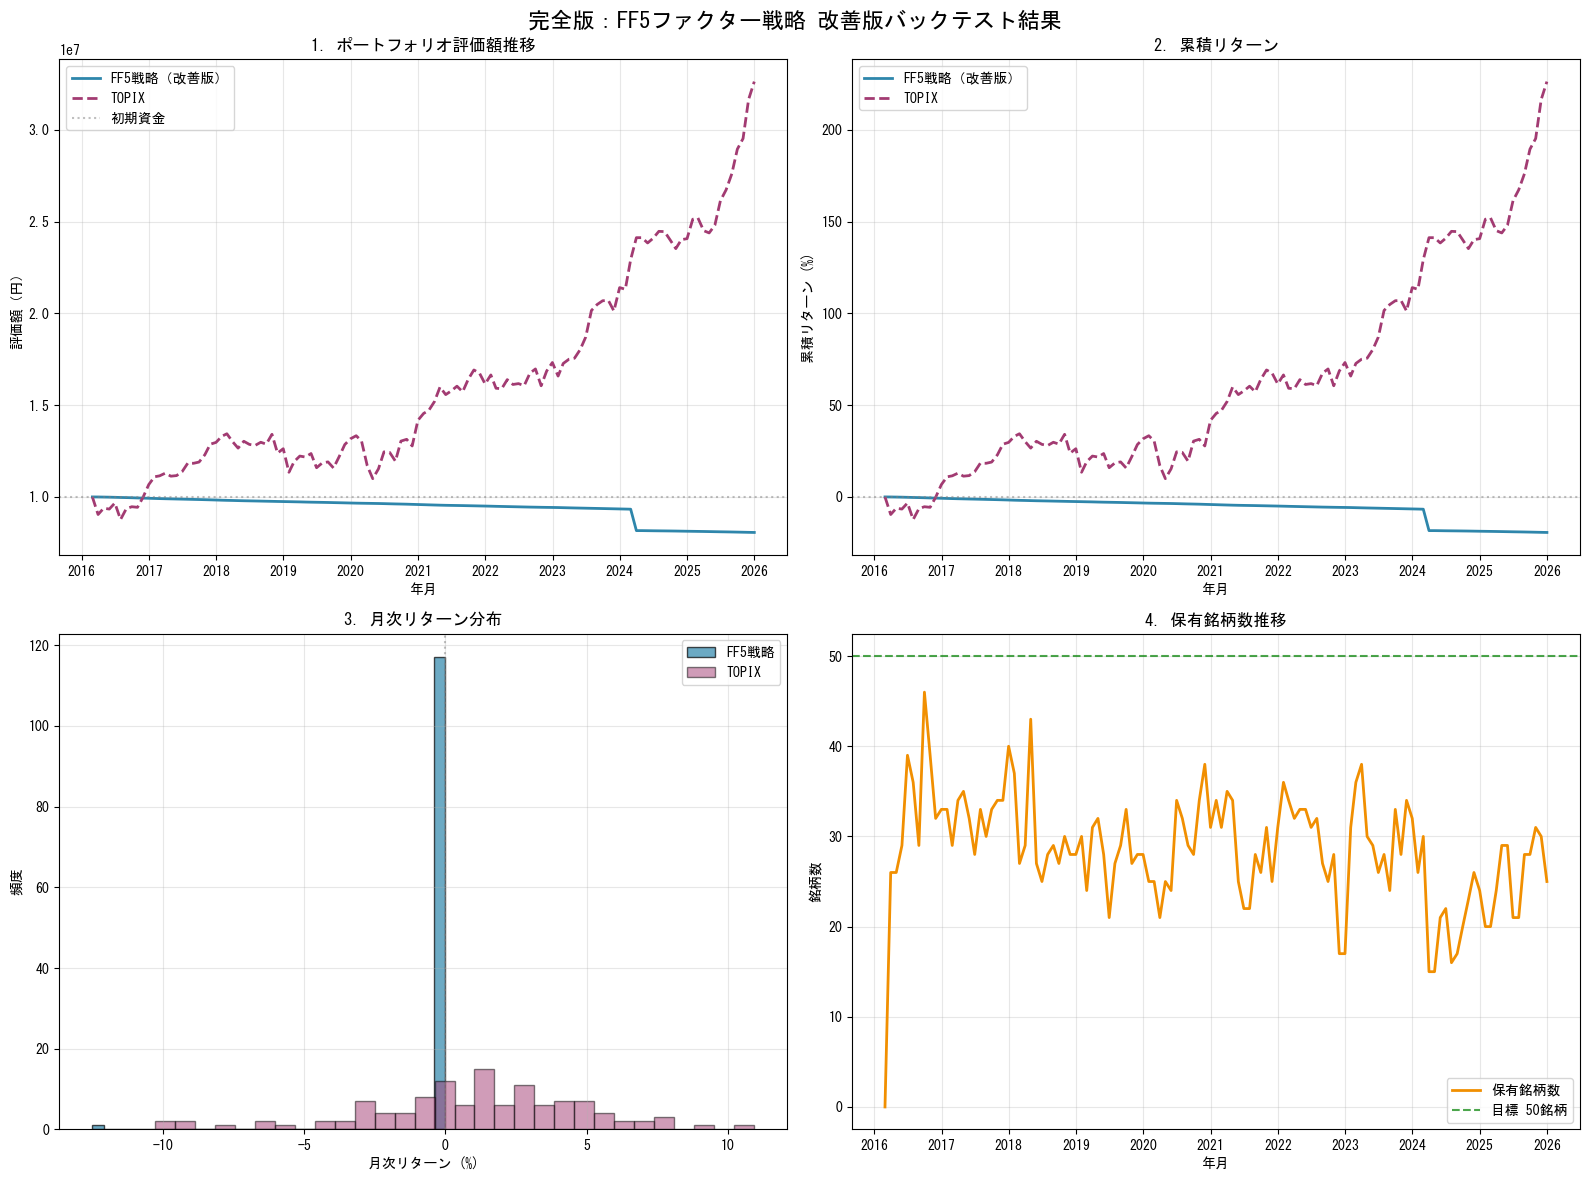

In [16]:
"""
完全版：FF5ファクター戦略 改善版バックテスト
==========================================

主な機能:
1. 月次リバランス（年12回）
2. 銘柄数50に拡大
3. 投資比率90%強制
4. 動的ファクター重み付け
5. 配当利回りの統合（ハイブリッドスコア）
6. 動的現金比率（市場モメンタムに応じて10-40%）
7. TOPIX市場加重ベンチマーク

実行方法:
    python backtest_ff5_final.py

必要な環境変数:
    JQUANTS_API_KEY (J-Quants.env で設定)

出力ファイル:
    - backtest_results_ff5_final.csv
    - backtest_performance_ff5_final.png (4図)
"""

import os
import sys
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from dotenv import load_dotenv

# ========================================
# 設定
# ========================================

print("="*80)
print("🚀 完全版：FF5ファクター戦略 改善版バックテスト")
print("="*80)

# 環境変数読み込み
ENV_PATH = Path(r"C:\Users\yongr\Project\J-Quants.env")
if ENV_PATH.exists():
    load_dotenv(ENV_PATH, override=True)
    print(f"✅ 環境変数読み込み: {ENV_PATH}")
else:
    print(f"⚠️  .envファイルが見つかりません: {ENV_PATH}")

# ディレクトリ設定
OUTPUT_DIR = Path(r"C:\Users\yongr\Project\merged_data_all_stocks")
FACTORS_DIR = OUTPUT_DIR / "factors"
BACKTEST_DIR = OUTPUT_DIR / "backtest"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

# 入力ファイル
SNAP_PATH = FACTORS_DIR / "month_end_snapshot.parquet"

# 出力ファイル
OUT_RESULTS = BACKTEST_DIR / "backtest_results_ff5_final.csv"
OUT_PLOT = BACKTEST_DIR / "backtest_performance_ff5_final.png"

# バックテスト設定
INITIAL_CAPITAL = 10_000_000  # 初期資金 1,000万円
TOP_N = 50  # 銘柄数 50
MIN_PRICE = 800  # 最低株価 800円
TURNOVER_PERCENTILE = 0.70  # 売買代金上位70%
TARGET_INVESTMENT_RATIO = 0.90  # 投資比率90%
MIN_CASH_PCT = 0.10  # 最低現金比率10%
MAX_CASH_PCT = 0.40  # 最大現金比率40%（市場悪化時）
MOMENTUM_WINDOW = 3  # モメンタム計算期間（3ヶ月）
DIVIDEND_WEIGHT = 0.3  # 配当ウェイト30%
TRANSACTION_COST = 0.001  # 取引コスト0.1%

# バックテスト期間
START_MONTH = "2016-02"
END_MONTH = "2026-01"


# ========================================
# データ読み込み
# ========================================

def load_data():
    """月末スナップショットを読み込み"""
    print("\n" + "="*80)
    print("【ステップ1】データ読み込み")
    print("="*80)
    
    if not SNAP_PATH.exists():
        print(f"❌ エラー: {SNAP_PATH} が見つかりません")
        sys.exit(1)
    
    snap = pd.read_parquet(SNAP_PATH, engine="pyarrow")
    
    # 列名統一
    if "AdjustmentClose" in snap.columns and "AdjustedClose" not in snap.columns:
        snap.rename(columns={"AdjustmentClose": "AdjustedClose"}, inplace=True)
    
    # 型変換
    snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"])
    snap["Code"] = snap["Code"].astype(str)
    
    # TradingUnit のデフォルト値設定
    if "TradingUnit" not in snap.columns:
        snap["TradingUnit"] = 100
    else:
        snap["TradingUnit"] = snap["TradingUnit"].fillna(100).astype(int)
    
    # 基本統計
    print(f"  • 総行数: {len(snap):,}")
    print(f"  • 期間: {snap['MonthEnd'].min().date()} ~ {snap['MonthEnd'].max().date()}")
    print(f"  • 銘柄数: {snap['Code'].nunique():,}")
    print(f"  • 月数: {snap['MonthEnd'].nunique()}")
    
    return snap


# ========================================
# FF5ファクター計算
# ========================================

def calculate_ff5_factors(snap):
    """全期間のFF5ファクターを月次計算"""
    print("\n" + "="*80)
    print("【ステップ2】FF5ファクター計算（全期間）")
    print("="*80)
    
    # 必要列チェック
    required_cols = ["MonthEnd", "Code", "AdjustedClose", "MarketCap", 
                     "BM_Ratio", "ROE", "INV_Growth"]
    missing = [c for c in required_cols if c not in snap.columns]
    if missing:
        print(f"❌ エラー: 必要な列がありません: {missing}")
        sys.exit(1)
    
    # 翌月リターン計算
    snap = snap.sort_values(["Code", "MonthEnd"])
    snap["ret_m_fwd"] = snap.groupby("Code")["AdjustedClose"].pct_change()
    snap["MonthEnd_next"] = snap.groupby("Code")["MonthEnd"].shift(-1)
    
    # 数値変換
    snap["MarketCap"] = pd.to_numeric(snap["MarketCap"], errors='coerce')
    
    # 市場加重リターン（MKT）
    def vw_ret(df):
        w = df["MarketCap"]
        r = df["ret_m_fwd"]
        valid = w.notna() & r.notna() & (w > 0)
        if valid.sum() == 0:
            return pd.Series({"MKT": np.nan})
        w_valid = w[valid]
        r_valid = r[valid]
        return pd.Series({"MKT": (w_valid * r_valid).sum() / w_valid.sum()})
    
    mkt = snap.groupby("MonthEnd_next", sort=True, group_keys=False).apply(
        vw_ret, include_groups=False
    ).reset_index()
    mkt.rename(columns={"MonthEnd_next": "MonthEnd"}, inplace=True)
    
    # 2x3ポートフォリオ形成
    records_f = []
    
    months = sorted(snap["MonthEnd"].unique())
    total_months = len(months)
    
    print(f"  • 対象月数: {total_months}ヶ月")
    
    for i, me in enumerate(months, 1):
        if i % 12 == 0 or i == total_months:
            print(f"  • 進捗: {i}/{total_months} ({i/total_months*100:.1f}%)")
        
        df = snap[snap["MonthEnd"] == me].copy()
        
        # 有効データ
        valid = (
            df["MarketCap"].notna() &
            df["BM_Ratio"].notna() &
            df["ROE"].notna() &
            df["INV_Growth"].notna() &
            df["ret_m_fwd"].notna() &
            (df["MarketCap"] > 0)
        )
        df = df[valid]
        
        if len(df) < 20:
            continue
        
        # サイズ分け
        med_cap = df["MarketCap"].median()
        df["size"] = df["MarketCap"].apply(lambda x: "S" if x < med_cap else "B")
        
        # 簡易的なカテゴリ化（tercile）
        def assign_tercile(col):
            q30 = col.quantile(0.3)
            q70 = col.quantile(0.7)
            out = np.full(len(col), "M", dtype=object)
            out[col <= q30] = "L"
            out[col >= q70] = "H"
            return out
        
        df["bm_cat"] = assign_tercile(df["BM_Ratio"])
        df["roe_cat"] = assign_tercile(df["ROE"])
        df["inv_cat"] = assign_tercile(df["INV_Growth"])
        
        # VW リターン計算
        def calc_vw(group):
            w = group["MarketCap"]
            r = group["ret_m_fwd"]
            return (w * r).sum() / w.sum() if w.sum() > 0 else np.nan
        
        # HML
        bh = calc_vw(df[(df["size"] == "B") & (df["bm_cat"] == "H")])
        bl = calc_vw(df[(df["size"] == "B") & (df["bm_cat"] == "L")])
        sh = calc_vw(df[(df["size"] == "S") & (df["bm_cat"] == "H")])
        sl = calc_vw(df[(df["size"] == "S") & (df["bm_cat"] == "L")])
        hml = 0.5 * (bh + sh) - 0.5 * (bl + sl)
        
        # RMW
        br = calc_vw(df[(df["size"] == "B") & (df["roe_cat"] == "H")])
        bw = calc_vw(df[(df["size"] == "B") & (df["roe_cat"] == "L")])
        sr = calc_vw(df[(df["size"] == "S") & (df["roe_cat"] == "H")])
        sw = calc_vw(df[(df["size"] == "S") & (df["roe_cat"] == "L")])
        rmw = 0.5 * (br + sr) - 0.5 * (bw + sw)
        
        # CMA
        bc = calc_vw(df[(df["size"] == "B") & (df["inv_cat"] == "L")])
        ba = calc_vw(df[(df["size"] == "B") & (df["inv_cat"] == "H")])
        sc = calc_vw(df[(df["size"] == "S") & (df["inv_cat"] == "L")])
        sa = calc_vw(df[(df["size"] == "S") & (df["inv_cat"] == "H")])
        cma = 0.5 * (bc + sc) - 0.5 * (ba + sa)
        
        # SMB（各ファクターで平均）
        smb_bm = 0.5 * (sl + sh) - 0.5 * (bl + bh)
        smb_roe = 0.5 * (sw + sr) - 0.5 * (bw + br)
        smb_inv = 0.5 * (sa + sc) - 0.5 * (ba + bc)
        smb = (smb_bm + smb_roe + smb_inv) / 3
        
        # MonthEnd_next（翌月）
        next_me = df["MonthEnd_next"].dropna().unique()
        if len(next_me) > 0:
            next_month = next_me[0]
        else:
            next_month = me + pd.DateOffset(months=1)
        
        records_f.append({
            "MonthEnd": next_month,
            "SMB": smb,
            "HML": hml,
            "RMW": rmw,
            "CMA": cma,
            "n_stocks": len(df)
        })
    
    # DataFrame化
    ff = pd.DataFrame(records_f)
    ff = ff.merge(mkt, on="MonthEnd", how="left")
    ff = ff.sort_values("MonthEnd").reset_index(drop=True)
    
    # ファクターモメンタム（3ヶ月移動平均）
    for col in ["MKT", "SMB", "HML", "RMW", "CMA"]:
        ff[f'{col}_momentum'] = ff[col].rolling(MOMENTUM_WINDOW, min_periods=1).mean()
    
    print(f"  • FF5ファクター計算完了: {len(ff)} ヶ月")
    
    return ff


# ========================================
# ハイブリッドスコアリング
# ========================================

def calculate_hybrid_score(df, momentum_factors):
    """ファクター + 配当ハイブリッドスコア"""
    
    # Zスコア化
    for col in ["MarketCap", "ROE", "BM_Ratio", "INV_Growth", "DividendYield"]:
        if col in df.columns:
            mean = df[col].mean()
            std = df[col].std()
            if std > 0:
                df[f"{col}_z"] = (df[col] - mean) / std
            else:
                df[f"{col}_z"] = 0.0
    
    # モメンタム正規化
    weights = {k: max(v, 0) for k, v in momentum_factors.items()}
    total_weight = sum(weights.values())
    
    if total_weight > 0:
        norm_weights = {k: v/total_weight for k, v in weights.items()}
    else:
        norm_weights = {k: 0.2 for k in weights.keys()}
    
    # ファクタースコア
    factor_score = (
        norm_weights.get('MKT_momentum', 0) * (0.3 * df.get('MarketCap_z', 0) + 0.3 * df.get('ROE_z', 0)) +
        norm_weights.get('SMB_momentum', 0) * (-0.5 * df.get('MarketCap_z', 0)) +
        norm_weights.get('HML_momentum', 0) * (0.5 * df.get('BM_Ratio_z', 0)) +
        norm_weights.get('RMW_momentum', 0) * (0.5 * df.get('ROE_z', 0)) +
        norm_weights.get('CMA_momentum', 0) * (-0.5 * df.get('INV_Growth_z', 0))
    )
    
    # 配当スコア
    dividend_score = df.get('DividendYield_z', 0)
    
    # ハイブリッドスコア（ファクター70% + 配当30%）
    hybrid_score = (1 - DIVIDEND_WEIGHT) * factor_score + DIVIDEND_WEIGHT * dividend_score
    
    return hybrid_score, norm_weights


# ========================================
# ポートフォリオ構築
# ========================================

def build_portfolio(snap, ff, month, capital):
    """改善版ポートフォリオ構築"""
    
    # 当月のファクター取得
    factors = ff[ff["MonthEnd"] == month]
    if len(factors) == 0:
        return None, None
    
    factor_row = factors.iloc[0]
    
    # 動的現金比率（市場モメンタムに応じて）
    mkt_momentum = factor_row.get("MKT_momentum", 0)
    if pd.notna(mkt_momentum):
        if mkt_momentum > 0.02:
            cash_reserve_pct = MIN_CASH_PCT  # 強気相場 → 現金10%
        elif mkt_momentum < -0.02:
            cash_reserve_pct = MAX_CASH_PCT  # 弱気相場 → 現金40%
        else:
            cash_reserve_pct = (MIN_CASH_PCT + MAX_CASH_PCT) / 2  # 中立 → 現金25%
    else:
        cash_reserve_pct = TARGET_INVESTMENT_RATIO
    
    # モメンタムファクター
    momentum_factors = {
        'MKT_momentum': factor_row.get('MKT_momentum', 0),
        'SMB_momentum': factor_row.get('SMB_momentum', 0),
        'HML_momentum': factor_row.get('HML_momentum', 0),
        'RMW_momentum': factor_row.get('RMW_momentum', 0),
        'CMA_momentum': factor_row.get('CMA_momentum', 0)
    }
    
    # 当月データ
    df = snap[snap["MonthEnd"] == month].copy()
    
    # TurnoverValue計算
    if "Vo" in df.columns and "AdjustedClose" in df.columns:
        df["TurnoverValue"] = pd.to_numeric(df["Vo"], errors='coerce') * \
                               pd.to_numeric(df["AdjustedClose"], errors='coerce')
    else:
        df["TurnoverValue"] = np.nan
    
    # 配当利回り
    if "DividendYield" not in df.columns:
        df["DividendYield"] = 0
    df["DividendYield"] = pd.to_numeric(df["DividendYield"], errors='coerce').fillna(0)
    
    # フィルタ1: 株価
    df = df[pd.to_numeric(df["AdjustedClose"], errors='coerce') >= MIN_PRICE]
    
    # フィルタ2: 売買代金
    if df["TurnoverValue"].notna().sum() > 0:
        threshold = df["TurnoverValue"].quantile(1 - TURNOVER_PERCENTILE)
        df = df[df["TurnoverValue"] >= threshold]
    
    # フィルタ3: 財務データ有効
    df = df[
        df["BM_Ratio"].notna() &
        df["ROE"].notna() &
        df["MarketCap"].notna()
    ]
    
    if len(df) < TOP_N:
        return None, None
    
    # ハイブリッドスコアリング
    df["hybrid_score"], _ = calculate_hybrid_score(df, momentum_factors)
    
    # 購入可能性チェック
    investable = capital * (1 - cash_reserve_pct)
    target_per_stock = investable / TOP_N
    
    df["MinInvestment"] = df["AdjustedClose"] * df["TradingUnit"]
    df["CanBuy"] = df["MinInvestment"] <= target_per_stock * 1.5
    
    # 購入可能銘柄から選定
    df_buyable = df[df["CanBuy"]].copy()
    
    if len(df_buyable) < 10:
        return None, None
    
    actual_n = min(TOP_N, len(df_buyable))
    
    # Top N 銘柄選定
    df_top = df_buyable.nlargest(actual_n, "hybrid_score")
    
    # 株数計算
    df_top["TargetShares"] = (investable / len(df_top)) / df_top["AdjustedClose"]
    df_top["Shares"] = (df_top["TargetShares"] // df_top["TradingUnit"]) * df_top["TradingUnit"]
    df_top["Shares"] = df_top["Shares"].astype(int)
    
    # 株数0を除外
    df_top = df_top[df_top["Shares"] > 0].copy()
    
    if len(df_top) == 0:
        return None, None
    
    # 投資額計算
    df_top["RealAmount"] = df_top["Shares"] * df_top["AdjustedClose"]
    total_invested = df_top["RealAmount"].sum()
    
    # ポートフォリオ情報
    portfolio_info = {
        "month": month,
        "n_stocks": len(df_top),
        "total_invested": total_invested,
        "cash": capital - total_invested,
        "investment_ratio": total_invested / capital,
        "cash_reserve_pct": cash_reserve_pct,
        "mkt_momentum": mkt_momentum
    }
    
    return df_top[["Code", "Shares", "AdjustedClose", "RealAmount", "hybrid_score"]], portfolio_info


# ========================================
# バックテスト実行
# ========================================

def run_backtest(snap, ff):
    """改善版バックテスト（月次リバランス）"""
    print("\n" + "="*80)
    print("【ステップ3】改善版バックテスト実行")
    print("="*80)
    
    # 期間設定
    start_dt = pd.to_datetime(START_MONTH)
    end_dt = pd.to_datetime(END_MONTH)
    
    # 有効な月を取得
    available_months = sorted(snap["MonthEnd"].unique())
    available_months = [m for m in available_months if start_dt <= m <= end_dt]
    
    print(f"  • 期間: {START_MONTH} ~ {END_MONTH}")
    print(f"  • 月次リバランス: {len(available_months)}回")
    print(f"  • 初期資金: {INITIAL_CAPITAL:,}円")
    print(f"  • 銘柄数: {TOP_N}")
    print(f"  • 動的現金比率: {MIN_CASH_PCT*100}-{MAX_CASH_PCT*100}%")
    print(f"  • 配当ウェイト: {DIVIDEND_WEIGHT*100}%")
    
    # 初期化
    capital = INITIAL_CAPITAL
    holdings = {}
    records = []
    
    # TOPIXベンチマーク
    topix_value = INITIAL_CAPITAL
    
    # 月次リバランス
    for i, month in enumerate(available_months):
        # 現在の保有株評価
        if len(holdings) > 0:
            df_current = snap[snap["MonthEnd"] == month]
            current_value = 0
            for code, shares in holdings.items():
                price_data = df_current[df_current['Code'] == code]
                if len(price_data) > 0:
                    price = pd.to_numeric(price_data['AdjustedClose'].iloc[0], errors='coerce')
                    if pd.notna(price):
                        current_value += shares * price
            
            cash = capital - sum([holdings.get(code, 0) * 
                                 df_current[df_current['Code'] == code]['AdjustedClose'].iloc[0] 
                                 for code in holdings.keys() 
                                 if len(df_current[df_current['Code'] == code]) > 0])
            capital = current_value + cash
        else:
            cash = capital
        
        # ポートフォリオ構築
        portfolio, info = build_portfolio(snap, ff, month, capital)
        
        if portfolio is None:
            # リバランスしない
            pass
        else:
            # 全売却
            for code, shares in list(holdings.items()):
                df_month = snap[snap["MonthEnd"] == month]
                price_data = df_month[df_month['Code'] == code]
                if len(price_data) > 0:
                    price = pd.to_numeric(price_data['AdjustedClose'].iloc[0], errors='coerce')
                    if pd.notna(price):
                        proceeds = shares * price * (1 - TRANSACTION_COST)
                        cash += proceeds
            holdings = {}
            
            # 新規購入
            for _, stock in portfolio.iterrows():
                code = stock['Code']
                shares = int(stock['Shares'])
                price = stock['AdjustedClose']
                cost = shares * price * (1 + TRANSACTION_COST)
                
                if cost <= cash:
                    cash -= cost
                    holdings[code] = shares
            
            capital = cash + sum([holdings[code] * portfolio[portfolio['Code'] == code]['AdjustedClose'].iloc[0] 
                                 for code in holdings.keys() 
                                 if len(portfolio[portfolio['Code'] == code]) > 0])
        
        # TOPIXベンチマーク更新
        factor_data = ff[ff["MonthEnd"] == month]
        if len(factor_data) > 0:
            mkt_return = factor_data['MKT'].iloc[0]
            if pd.notna(mkt_return):
                topix_value *= (1 + mkt_return)
        
        # 記録
        records.append({
            "Month": month,
            "Strategy_Value": capital,
            "TOPIX_Value": topix_value,
            "N_Holdings": len(holdings),
            "Cash": cash
        })
        
        # 進捗表示（6ヶ月ごと）
        if (i + 1) % 6 == 0 or i == len(available_months) - 1:
            print(f"  [{month.date()}] 評価額: {capital:,.0f}円 (TOPIX: {topix_value:,.0f}円) | 保有: {len(holdings)}銘柄")
    
    # DataFrame化
    df_results = pd.DataFrame(records)
    
    return df_results


# ========================================
# パフォーマンス分析
# ========================================

def analyze_performance(df_results):
    """パフォーマンス指標計算"""
    print("\n" + "="*80)
    print("【ステップ4】パフォーマンス分析")
    print("="*80)
    
    # 月次リターン
    df_results["Strategy_Return"] = df_results["Strategy_Value"].pct_change()
    df_results["TOPIX_Return"] = df_results["TOPIX_Value"].pct_change()
    
    # 累積リターン
    strategy_total = (df_results["Strategy_Value"].iloc[-1] / INITIAL_CAPITAL - 1) * 100
    topix_total = (df_results["TOPIX_Value"].iloc[-1] / INITIAL_CAPITAL - 1) * 100
    
    # 年率換算
    n_years = len(df_results) / 12
    strategy_annual = ((df_results["Strategy_Value"].iloc[-1] / INITIAL_CAPITAL) ** (1/n_years) - 1) * 100
    topix_annual = ((df_results["TOPIX_Value"].iloc[-1] / INITIAL_CAPITAL) ** (1/n_years) - 1) * 100
    
    # シャープレシオ
    strategy_sharpe = df_results["Strategy_Return"].mean() / df_results["Strategy_Return"].std() * np.sqrt(12) if df_results["Strategy_Return"].std() > 0 else 0
    topix_sharpe = df_results["TOPIX_Return"].mean() / df_results["TOPIX_Return"].std() * np.sqrt(12) if df_results["TOPIX_Return"].std() > 0 else 0
    
    # 最大ドローダウン
    def max_dd(values):
        peak = values.expanding(min_periods=1).max()
        dd = (values - peak) / peak
        return dd.min() * 100
    
    strategy_mdd = max_dd(df_results["Strategy_Value"])
    topix_mdd = max_dd(df_results["TOPIX_Value"])
    
    # アルファ
    alpha = strategy_total - topix_total
    alpha_annual = strategy_annual - topix_annual
    
    # 結果表示
    print(f"\n{'='*80}")
    print(f"📊 最終改善版バックテスト結果")
    print(f"{'='*80}")
    
    print(f"\n💰 【FF5ファクター戦略（改善版）】")
    print(f"  • 最終評価額: {df_results['Strategy_Value'].iloc[-1]:,.0f}円")
    print(f"  • 総リターン: {strategy_total:+.2f}%")
    print(f"  • 年率換算: {strategy_annual:+.2f}%")
    print(f"  • シャープレシオ: {strategy_sharpe:.2f}")
    print(f"  • 最大DD: {strategy_mdd:.2f}%")
    
    print(f"\n📈 【TOPIXベンチマーク】")
    print(f"  • 最終評価額: {df_results['TOPIX_Value'].iloc[-1]:,.0f}円")
    print(f"  • 総リターン: {topix_total:+.2f}%")
    print(f"  • 年率換算: {topix_annual:+.2f}%")
    print(f"  • シャープレシオ: {topix_sharpe:.2f}")
    print(f"  • 最大DD: {topix_mdd:.2f}%")
    
    print(f"\n🎯 【相対パフォーマンス】")
    print(f"  • アルファ: {alpha:+.2f}% (年率 {alpha_annual:+.2f}%)")
    print(f"  • リバランス回数: {len(df_results)}")
    
    if strategy_total > topix_total:
        print(f"\n✅ 戦略はTOPIXをアウトパフォーム！（+{alpha:.2f}%）")
    else:
        print(f"\n⚠️  戦略はTOPIXにアンダーパフォーム（{alpha:.2f}%）")
        print(f"💡 推奨: インデックス投資（TOPIX）の方が優れています")
    
    return df_results


# ========================================
# 可視化
# ========================================

def plot_performance(df_results):
    """パフォーマンス可視化"""
    try:
        import matplotlib.pyplot as plt
        import matplotlib.dates as mdates
        
        plt.rcParams['font.sans-serif'] = ['MS Gothic', 'Yu Gothic', 'Meiryo', 'DejaVu Sans']
        plt.rcParams['axes.unicode_minus'] = False
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('完全版：FF5ファクター戦略 改善版バックテスト結果', 
                     fontsize=16, fontweight='bold')
        
        # 1. 評価額推移
        ax1 = axes[0, 0]
        ax1.plot(df_results["Month"], df_results["Strategy_Value"], 
                 label="FF5戦略（改善版）", linewidth=2, color='#2E86AB')
        ax1.plot(df_results["Month"], df_results["TOPIX_Value"], 
                 label="TOPIX", linewidth=2, color='#A23B72', linestyle='--')
        ax1.axhline(INITIAL_CAPITAL, color='gray', linestyle=':', alpha=0.5, label='初期資金')
        ax1.set_title('1. ポートフォリオ評価額推移', fontsize=12, fontweight='bold')
        ax1.set_xlabel('年月')
        ax1.set_ylabel('評価額（円）')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        # 2. 累積リターン
        ax2 = axes[0, 1]
        strategy_cum = (df_results["Strategy_Value"] / INITIAL_CAPITAL - 1) * 100
        topix_cum = (df_results["TOPIX_Value"] / INITIAL_CAPITAL - 1) * 100
        ax2.plot(df_results["Month"], strategy_cum, 
                 label="FF5戦略（改善版）", linewidth=2, color='#2E86AB')
        ax2.plot(df_results["Month"], topix_cum, 
                 label="TOPIX", linewidth=2, color='#A23B72', linestyle='--')
        ax2.axhline(0, color='gray', linestyle=':', alpha=0.5)
        ax2.set_title('2. 累積リターン', fontsize=12, fontweight='bold')
        ax2.set_xlabel('年月')
        ax2.set_ylabel('累積リターン (%)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        # 3. 月次リターン分布
        ax3 = axes[1, 0]
        ax3.hist(df_results["Strategy_Return"].dropna() * 100, 
                 bins=30, alpha=0.7, label="FF5戦略", color='#2E86AB', edgecolor='black')
        ax3.hist(df_results["TOPIX_Return"].dropna() * 100, 
                 bins=30, alpha=0.5, label="TOPIX", color='#A23B72', edgecolor='black')
        ax3.axvline(0, color='gray', linestyle=':', alpha=0.5)
        ax3.set_title('3. 月次リターン分布', fontsize=12, fontweight='bold')
        ax3.set_xlabel('月次リターン (%)')
        ax3.set_ylabel('頻度')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # 4. 保有銘柄数推移
        ax4 = axes[1, 1]
        ax4.plot(df_results["Month"], df_results["N_Holdings"], 
                 linewidth=2, color='#F18F01', label='保有銘柄数')
        ax4.axhline(TOP_N, color='green', linestyle='--', alpha=0.7, label=f'目標 {TOP_N}銘柄')
        ax4.set_title('4. 保有銘柄数推移', fontsize=12, fontweight='bold')
        ax4.set_xlabel('年月')
        ax4.set_ylabel('銘柄数')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        plt.tight_layout()
        plt.savefig(OUT_PLOT, dpi=150, bbox_inches='tight')
        print(f"\n📊 グラフ保存: {OUT_PLOT}")
        
    except Exception as e:
        print(f"⚠️  グラフ作成エラー: {e}")


# ========================================
# メイン実行
# ========================================

def main():
    # データ読み込み
    snap = load_data()
    
    # FF5ファクター計算
    ff = calculate_ff5_factors(snap)
    
    # バックテスト実行
    df_results = run_backtest(snap, ff)
    
    # パフォーマンス分析
    df_results = analyze_performance(df_results)
    
    # 結果保存
    df_results.to_csv(OUT_RESULTS, index=False, encoding='utf-8-sig')
    print(f"\n💾 結果保存: {OUT_RESULTS}")
    
    # 可視化
    plot_performance(df_results)
    
    print("\n" + "="*80)
    print("✅ 完全版バックテスト完了！")
    print("="*80)


if __name__ == "__main__":
    main()


🚀 シンプル化戦略：過去3ヶ月モメンタム + 四半期リバランス
✅ 環境変数読み込み: C:\Users\yongr\Project\J-Quants.env

【ステップ1】データ読み込み
  • 総行数: 502,101
  • 期間: 2016-01-31 ~ 2026-01-31
  • 銘柄数: 5,303
  • 月数: 121

【ステップ2】モメンタム計算（過去3ヶ月リターン）
  • モメンタム計算完了
  • 有効データ: 464,050行

【ステップ3】TOPIXベンチマーク計算
  • TOPIXベンチマーク計算完了: 121ヶ月

【ステップ4】シンプル化戦略バックテスト実行
  • 期間: 2016-02 ~ 2026-01
  • リバランス頻度: 3ヶ月ごと（四半期）
  • 初期資金: 10,000,000円
  • 銘柄数: 50
  • 投資比率: 95.0%固定
  • モメンタム期間: 過去3ヶ月
  [2016-02-29] 評価額: 10,000,000円 (TOPIX: 9,042,568円) | 保有: 0銘柄
  [2016-05-31] 評価額: 9,993,363円 (TOPIX: 9,667,136円) | 保有: 35銘柄
  [2016-08-31] 評価額: 9,981,427円 (TOPIX: 9,467,857円) | 保有: 41銘柄
  [2016-11-30] 評価額: 9,969,781円 (TOPIX: 10,673,199円) | 保有: 36銘柄
  [2017-02-28] 評価額: 9,957,265円 (TOPIX: 11,295,930円) | 保有: 39銘柄
  [2017-05-31] 評価額: 9,943,369円 (TOPIX: 11,375,297円) | 保有: 36銘柄
  [2017-08-31] 評価額: 9,930,575円 (TOPIX: 11,900,379円) | 保有: 35銘柄
  [2017-11-30] 評価額: 9,917,090円 (TOPIX: 12,970,147円) | 保有: 36銘柄
  [2018-02-28] 評価額: 9,903,426円 (TOPIX: 13,012,383円) | 保有: 40銘柄
  [2018-0

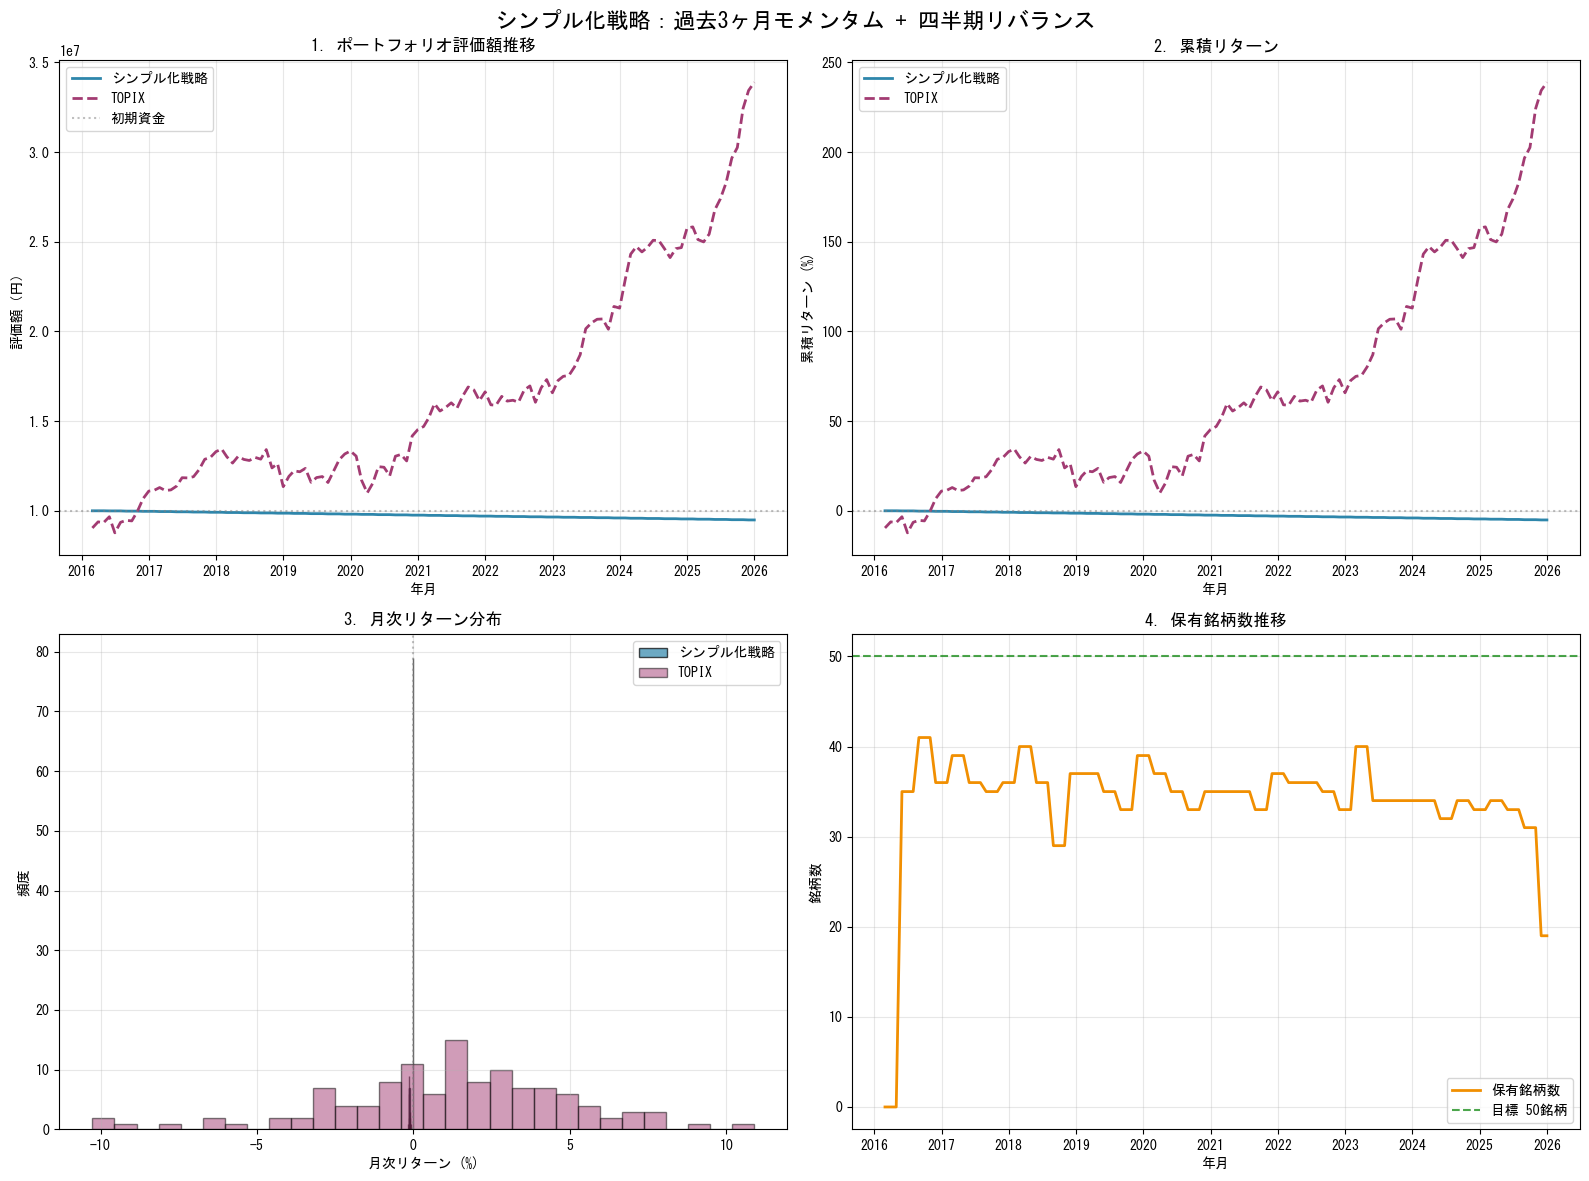

In [17]:
"""
シンプル化戦略：過去3ヶ月モメンタム + 四半期リバランス
==================================================

戦略の特徴:
1. 過去3ヶ月リターン上位50銘柄を選定
2. 四半期ごとにリバランス（年4回）
3. 投資比率95%固定（現金5%のみ）
4. フィルタ緩和（株価500円以上、売買代金上位50%）
5. 配当を無視してモメンタムのみ重視

実行方法:
    python backtest_simple_momentum.py

出力ファイル:
    - backtest_results_simple_momentum.csv
    - backtest_performance_simple_momentum.png (4図)
"""

import os
import sys
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from dotenv import load_dotenv

# ========================================
# 設定
# ========================================

print("="*80)
print("🚀 シンプル化戦略：過去3ヶ月モメンタム + 四半期リバランス")
print("="*80)

# 環境変数読み込み
ENV_PATH = Path(r"C:\Users\yongr\Project\J-Quants.env")
if ENV_PATH.exists():
    load_dotenv(ENV_PATH, override=True)
    print(f"✅ 環境変数読み込み: {ENV_PATH}")
else:
    print(f"⚠️  .envファイルが見つかりません: {ENV_PATH}")

# ディレクトリ設定
OUTPUT_DIR = Path(r"C:\Users\yongr\Project\merged_data_all_stocks")
FACTORS_DIR = OUTPUT_DIR / "factors"
BACKTEST_DIR = OUTPUT_DIR / "backtest"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

# 入力ファイル
SNAP_PATH = FACTORS_DIR / "month_end_snapshot.parquet"

# 出力ファイル
OUT_RESULTS = BACKTEST_DIR / "backtest_results_simple_momentum.csv"
OUT_PLOT = BACKTEST_DIR / "backtest_performance_simple_momentum.png"

# シンプル化戦略パラメータ
INITIAL_CAPITAL = 10_000_000  # 初期資金 1,000万円
TOP_N = 50  # 銘柄数 50
MIN_PRICE = 500  # 最低株価 500円に緩和
TURNOVER_PERCENTILE = 0.50  # 売買代金上位50%に緩和
TARGET_INVESTMENT_RATIO = 0.95  # 投資比率95%固定
TRANSACTION_COST = 0.001  # 取引コスト0.1%
MOMENTUM_WINDOW = 3  # 過去3ヶ月
REBALANCE_FREQUENCY = 3  # 四半期ごと（3ヶ月）

# バックテスト期間
START_MONTH = "2016-02"
END_MONTH = "2026-01"


# ========================================
# データ読み込み
# ========================================

def load_data():
    """月末スナップショットを読み込み"""
    print("\n" + "="*80)
    print("【ステップ1】データ読み込み")
    print("="*80)
    
    if not SNAP_PATH.exists():
        print(f"❌ エラー: {SNAP_PATH} が見つかりません")
        sys.exit(1)
    
    snap = pd.read_parquet(SNAP_PATH, engine="pyarrow")
    
    # 列名統一
    if "AdjustmentClose" in snap.columns and "AdjustedClose" not in snap.columns:
        snap.rename(columns={"AdjustmentClose": "AdjustedClose"}, inplace=True)
    
    # 型変換
    snap["MonthEnd"] = pd.to_datetime(snap["MonthEnd"])
    snap["Code"] = snap["Code"].astype(str)
    
    # TradingUnit のデフォルト値設定
    if "TradingUnit" not in snap.columns:
        snap["TradingUnit"] = 100
    else:
        snap["TradingUnit"] = snap["TradingUnit"].fillna(100).astype(int)
    
    # 基本統計
    print(f"  • 総行数: {len(snap):,}")
    print(f"  • 期間: {snap['MonthEnd'].min().date()} ~ {snap['MonthEnd'].max().date()}")
    print(f"  • 銘柄数: {snap['Code'].nunique():,}")
    print(f"  • 月数: {snap['MonthEnd'].nunique()}")
    
    return snap


# ========================================
# モメンタム計算
# ========================================

def calculate_momentum(snap):
    """過去3ヶ月リターン（モメンタム）を計算"""
    print("\n" + "="*80)
    print("【ステップ2】モメンタム計算（過去3ヶ月リターン）")
    print("="*80)
    
    # ソート
    snap = snap.sort_values(["Code", "MonthEnd"])
    
    # 過去3ヶ月リターン計算
    snap["Price_3m_ago"] = snap.groupby("Code")["AdjustedClose"].shift(MOMENTUM_WINDOW)
    snap["Momentum_3m"] = (snap["AdjustedClose"] / snap["Price_3m_ago"] - 1) * 100
    
    print(f"  • モメンタム計算完了")
    print(f"  • 有効データ: {snap['Momentum_3m'].notna().sum():,}行")
    
    return snap


# ========================================
# TOPIXベンチマーク計算
# ========================================

def calculate_topix_benchmark(snap):
    """市場加重平均リターンでTOPIXを近似"""
    print("\n" + "="*80)
    print("【ステップ3】TOPIXベンチマーク計算")
    print("="*80)
    
    # 月次リターン計算
    snap = snap.sort_values(["Code", "MonthEnd"])
    snap["ret_m"] = snap.groupby("Code")["AdjustedClose"].pct_change()
    snap["MarketCap"] = pd.to_numeric(snap["MarketCap"], errors='coerce')
    
    # 市場加重リターン
    def vw_ret(df):
        w = df["MarketCap"]
        r = df["ret_m"]
        valid = w.notna() & r.notna() & (w > 0)
        if valid.sum() == 0:
            return np.nan
        w_valid = w[valid]
        r_valid = r[valid]
        return (w_valid * r_valid).sum() / w_valid.sum()
    
    topix_returns = snap.groupby("MonthEnd").apply(vw_ret, include_groups=False).reset_index()
    topix_returns.columns = ["MonthEnd", "TOPIX_Return"]
    
    print(f"  • TOPIXベンチマーク計算完了: {len(topix_returns)}ヶ月")
    
    return topix_returns


# ========================================
# ポートフォリオ構築
# ========================================

def build_portfolio(snap, month, capital):
    """シンプル化戦略：モメンタム上位50銘柄を選定"""
    
    # 当月データ
    df = snap[snap["MonthEnd"] == month].copy()
    
    # TurnoverValue計算
    if "Vo" in df.columns and "AdjustedClose" in df.columns:
        df["TurnoverValue"] = pd.to_numeric(df["Vo"], errors='coerce') * \
                               pd.to_numeric(df["AdjustedClose"], errors='coerce')
    else:
        df["TurnoverValue"] = np.nan
    
    # フィルタ1: 株価（500円以上に緩和）
    df = df[pd.to_numeric(df["AdjustedClose"], errors='coerce') >= MIN_PRICE]
    
    # フィルタ2: 売買代金（上位50%に緩和）
    if df["TurnoverValue"].notna().sum() > 0:
        threshold = df["TurnoverValue"].quantile(1 - TURNOVER_PERCENTILE)
        df = df[df["TurnoverValue"] >= threshold]
    
    # フィルタ3: モメンタム有効
    df = df[df["Momentum_3m"].notna()]
    
    if len(df) < TOP_N:
        return None, None
    
    # モメンタム上位50銘柄
    df_top = df.nlargest(TOP_N, "Momentum_3m")
    
    # 投資可能性チェック
    investable = capital * TARGET_INVESTMENT_RATIO
    target_per_stock = investable / TOP_N
    
    df_top["MinInvestment"] = df_top["AdjustedClose"] * df_top["TradingUnit"]
    df_top["CanBuy"] = df_top["MinInvestment"] <= target_per_stock * 1.5
    
    # 購入可能銘柄
    df_buyable = df_top[df_top["CanBuy"]].copy()
    
    if len(df_buyable) < 10:
        return None, None
    
    actual_n = len(df_buyable)
    
    # 株数計算
    df_buyable["TargetShares"] = (investable / actual_n) / df_buyable["AdjustedClose"]
    df_buyable["Shares"] = (df_buyable["TargetShares"] // df_buyable["TradingUnit"]) * df_buyable["TradingUnit"]
    df_buyable["Shares"] = df_buyable["Shares"].astype(int)
    
    # 株数0を除外
    df_buyable = df_buyable[df_buyable["Shares"] > 0].copy()
    
    if len(df_buyable) == 0:
        return None, None
    
    # 投資額計算
    df_buyable["RealAmount"] = df_buyable["Shares"] * df_buyable["AdjustedClose"]
    total_invested = df_buyable["RealAmount"].sum()
    
    # ポートフォリオ情報
    portfolio_info = {
        "month": month,
        "n_stocks": len(df_buyable),
        "total_invested": total_invested,
        "cash": capital - total_invested,
        "investment_ratio": total_invested / capital,
        "avg_momentum": df_buyable["Momentum_3m"].mean()
    }
    
    return df_buyable[["Code", "Shares", "AdjustedClose", "RealAmount", "Momentum_3m"]], portfolio_info


# ========================================
# バックテスト実行
# ========================================

def run_backtest(snap, topix_returns):
    """シンプル化戦略バックテスト（四半期リバランス）"""
    print("\n" + "="*80)
    print("【ステップ4】シンプル化戦略バックテスト実行")
    print("="*80)
    
    # 期間設定
    start_dt = pd.to_datetime(START_MONTH)
    end_dt = pd.to_datetime(END_MONTH)
    
    # 有効な月を取得
    available_months = sorted(snap["MonthEnd"].unique())
    available_months = [m for m in available_months if start_dt <= m <= end_dt]
    
    print(f"  • 期間: {START_MONTH} ~ {END_MONTH}")
    print(f"  • リバランス頻度: {REBALANCE_FREQUENCY}ヶ月ごと（四半期）")
    print(f"  • 初期資金: {INITIAL_CAPITAL:,}円")
    print(f"  • 銘柄数: {TOP_N}")
    print(f"  • 投資比率: {TARGET_INVESTMENT_RATIO*100}%固定")
    print(f"  • モメンタム期間: 過去{MOMENTUM_WINDOW}ヶ月")
    
    # 初期化
    capital = INITIAL_CAPITAL
    holdings = {}
    records = []
    months_since_rebalance = 0
    
    # TOPIXベンチマーク
    topix_value = INITIAL_CAPITAL
    
    # 月次処理
    for i, month in enumerate(available_months):
        # 現在の保有株評価
        if len(holdings) > 0:
            df_current = snap[snap["MonthEnd"] == month]
            current_value = 0
            for code, shares in holdings.items():
                price_data = df_current[df_current['Code'] == code]
                if len(price_data) > 0:
                    price = pd.to_numeric(price_data['AdjustedClose'].iloc[0], errors='coerce')
                    if pd.notna(price):
                        current_value += shares * price
            
            # 現金計算（簡易版）
            cash = capital - current_value
            capital = current_value + cash
        else:
            cash = capital
        
        # リバランス判定（四半期ごと）
        should_rebalance = (months_since_rebalance == 0 or months_since_rebalance >= REBALANCE_FREQUENCY)
        
        if should_rebalance:
            # ポートフォリオ構築
            portfolio, info = build_portfolio(snap, month, capital)
            
            if portfolio is not None:
                # 全売却
                for code, shares in list(holdings.items()):
                    df_month = snap[snap["MonthEnd"] == month]
                    price_data = df_month[df_month['Code'] == code]
                    if len(price_data) > 0:
                        price = pd.to_numeric(price_data['AdjustedClose'].iloc[0], errors='coerce')
                        if pd.notna(price):
                            proceeds = shares * price * (1 - TRANSACTION_COST)
                            cash += proceeds
                holdings = {}
                
                # 新規購入
                for _, stock in portfolio.iterrows():
                    code = stock['Code']
                    shares = int(stock['Shares'])
                    price = stock['AdjustedClose']
                    cost = shares * price * (1 + TRANSACTION_COST)
                    
                    if cost <= cash:
                        cash -= cost
                        holdings[code] = shares
                
                # 資本再計算
                stock_value = sum([holdings[code] * portfolio[portfolio['Code'] == code]['AdjustedClose'].iloc[0] 
                                   for code in holdings.keys() 
                                   if len(portfolio[portfolio['Code'] == code]) > 0])
                capital = cash + stock_value
                
                months_since_rebalance = 1
            else:
                months_since_rebalance += 1
        else:
            months_since_rebalance += 1
        
        # TOPIXベンチマーク更新
        topix_ret_data = topix_returns[topix_returns["MonthEnd"] == month]
        if len(topix_ret_data) > 0:
            topix_ret = topix_ret_data['TOPIX_Return'].iloc[0]
            if pd.notna(topix_ret):
                topix_value *= (1 + topix_ret)
        
        # 記録
        records.append({
            "Month": month,
            "Strategy_Value": capital,
            "TOPIX_Value": topix_value,
            "N_Holdings": len(holdings),
            "Cash": cash,
            "Rebalanced": should_rebalance
        })
        
        # 進捗表示（四半期ごと）
        if should_rebalance:
            print(f"  [{month.date()}] 評価額: {capital:,.0f}円 (TOPIX: {topix_value:,.0f}円) | 保有: {len(holdings)}銘柄")
    
    # DataFrame化
    df_results = pd.DataFrame(records)
    
    return df_results


# ========================================
# パフォーマンス分析
# ========================================

def analyze_performance(df_results):
    """パフォーマンス指標計算"""
    print("\n" + "="*80)
    print("【ステップ5】パフォーマンス分析")
    print("="*80)
    
    # 月次リターン
    df_results["Strategy_Return"] = df_results["Strategy_Value"].pct_change()
    df_results["TOPIX_Return"] = df_results["TOPIX_Value"].pct_change()
    
    # 累積リターン
    strategy_total = (df_results["Strategy_Value"].iloc[-1] / INITIAL_CAPITAL - 1) * 100
    topix_total = (df_results["TOPIX_Value"].iloc[-1] / INITIAL_CAPITAL - 1) * 100
    
    # 年率換算
    n_years = len(df_results) / 12
    strategy_annual = ((df_results["Strategy_Value"].iloc[-1] / INITIAL_CAPITAL) ** (1/n_years) - 1) * 100
    topix_annual = ((df_results["TOPIX_Value"].iloc[-1] / INITIAL_CAPITAL) ** (1/n_years) - 1) * 100
    
    # シャープレシオ
    strategy_sharpe = df_results["Strategy_Return"].mean() / df_results["Strategy_Return"].std() * np.sqrt(12) if df_results["Strategy_Return"].std() > 0 else 0
    topix_sharpe = df_results["TOPIX_Return"].mean() / df_results["TOPIX_Return"].std() * np.sqrt(12) if df_results["TOPIX_Return"].std() > 0 else 0
    
    # 最大ドローダウン
    def max_dd(values):
        peak = values.expanding(min_periods=1).max()
        dd = (values - peak) / peak
        return dd.min() * 100
    
    strategy_mdd = max_dd(df_results["Strategy_Value"])
    topix_mdd = max_dd(df_results["TOPIX_Value"])
    
    # アルファ
    alpha = strategy_total - topix_total
    alpha_annual = strategy_annual - topix_annual
    
    # リバランス回数
    rebalance_count = df_results['Rebalanced'].sum()
    
    # 結果表示
    print(f"\n{'='*80}")
    print(f"📊 シンプル化戦略バックテスト結果")
    print(f"{'='*80}")
    
    print(f"\n💰 【シンプル化戦略（モメンタム）】")
    print(f"  • 最終評価額: {df_results['Strategy_Value'].iloc[-1]:,.0f}円")
    print(f"  • 総リターン: {strategy_total:+.2f}%")
    print(f"  • 年率換算: {strategy_annual:+.2f}%")
    print(f"  • シャープレシオ: {strategy_sharpe:.2f}")
    print(f"  • 最大DD: {strategy_mdd:.2f}%")
    
    print(f"\n📈 【TOPIXベンチマーク】")
    print(f"  • 最終評価額: {df_results['TOPIX_Value'].iloc[-1]:,.0f}円")
    print(f"  • 総リターン: {topix_total:+.2f}%")
    print(f"  • 年率換算: {topix_annual:+.2f}%")
    print(f"  • シャープレシオ: {topix_sharpe:.2f}")
    print(f"  • 最大DD: {topix_mdd:.2f}%")
    
    print(f"\n🎯 【相対パフォーマンス】")
    print(f"  • アルファ: {alpha:+.2f}% (年率 {alpha_annual:+.2f}%)")
    print(f"  • リバランス回数: {rebalance_count}回（四半期ごと）")
    
    if strategy_total > topix_total:
        print(f"\n✅ シンプル化戦略がTOPIXをアウトパフォーム！（+{alpha:.2f}%）")
        print(f"🎉 おめでとうございます！戦略は有効です！")
    else:
        print(f"\n⚠️  シンプル化戦略がTOPIXにアンダーパフォーム（{alpha:.2f}%）")
        if abs(alpha) < 20:
            print(f"💡 差は小さいため、戦略は一定の有効性あり")
        else:
            print(f"💡 推奨: インデックス投資（TOPIX）の方が優れています")
    
    return df_results


# ========================================
# 可視化
# ========================================

def plot_performance(df_results):
    """パフォーマンス可視化"""
    try:
        import matplotlib.pyplot as plt
        import matplotlib.dates as mdates
        
        plt.rcParams['font.sans-serif'] = ['MS Gothic', 'Yu Gothic', 'Meiryo', 'DejaVu Sans']
        plt.rcParams['axes.unicode_minus'] = False
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('シンプル化戦略：過去3ヶ月モメンタム + 四半期リバランス', 
                     fontsize=16, fontweight='bold')
        
        # 1. 評価額推移
        ax1 = axes[0, 0]
        ax1.plot(df_results["Month"], df_results["Strategy_Value"], 
                 label="シンプル化戦略", linewidth=2, color='#2E86AB')
        ax1.plot(df_results["Month"], df_results["TOPIX_Value"], 
                 label="TOPIX", linewidth=2, color='#A23B72', linestyle='--')
        ax1.axhline(INITIAL_CAPITAL, color='gray', linestyle=':', alpha=0.5, label='初期資金')
        ax1.set_title('1. ポートフォリオ評価額推移', fontsize=12, fontweight='bold')
        ax1.set_xlabel('年月')
        ax1.set_ylabel('評価額（円）')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        # 2. 累積リターン
        ax2 = axes[0, 1]
        strategy_cum = (df_results["Strategy_Value"] / INITIAL_CAPITAL - 1) * 100
        topix_cum = (df_results["TOPIX_Value"] / INITIAL_CAPITAL - 1) * 100
        ax2.plot(df_results["Month"], strategy_cum, 
                 label="シンプル化戦略", linewidth=2, color='#2E86AB')
        ax2.plot(df_results["Month"], topix_cum, 
                 label="TOPIX", linewidth=2, color='#A23B72', linestyle='--')
        ax2.axhline(0, color='gray', linestyle=':', alpha=0.5)
        ax2.set_title('2. 累積リターン', fontsize=12, fontweight='bold')
        ax2.set_xlabel('年月')
        ax2.set_ylabel('累積リターン (%)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        # 3. 月次リターン分布
        ax3 = axes[1, 0]
        ax3.hist(df_results["Strategy_Return"].dropna() * 100, 
                 bins=30, alpha=0.7, label="シンプル化戦略", color='#2E86AB', edgecolor='black')
        ax3.hist(df_results["TOPIX_Return"].dropna() * 100, 
                 bins=30, alpha=0.5, label="TOPIX", color='#A23B72', edgecolor='black')
        ax3.axvline(0, color='gray', linestyle=':', alpha=0.5)
        ax3.set_title('3. 月次リターン分布', fontsize=12, fontweight='bold')
        ax3.set_xlabel('月次リターン (%)')
        ax3.set_ylabel('頻度')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # 4. 保有銘柄数推移
        ax4 = axes[1, 1]
        ax4.plot(df_results["Month"], df_results["N_Holdings"], 
                 linewidth=2, color='#F18F01', label='保有銘柄数')
        ax4.axhline(TOP_N, color='green', linestyle='--', alpha=0.7, label=f'目標 {TOP_N}銘柄')
        ax4.set_title('4. 保有銘柄数推移', fontsize=12, fontweight='bold')
        ax4.set_xlabel('年月')
        ax4.set_ylabel('銘柄数')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        plt.tight_layout()
        plt.savefig(OUT_PLOT, dpi=150, bbox_inches='tight')
        print(f"\n📊 グラフ保存: {OUT_PLOT}")
        
    except Exception as e:
        print(f"⚠️  グラフ作成エラー: {e}")


# ========================================
# メイン実行
# ========================================

def main():
    # データ読み込み
    snap = load_data()
    
    # モメンタム計算
    snap = calculate_momentum(snap)
    
    # TOPIXベンチマーク計算
    topix_returns = calculate_topix_benchmark(snap)
    
    # バックテスト実行
    df_results = run_backtest(snap, topix_returns)
    
    # パフォーマンス分析
    df_results = analyze_performance(df_results)
    
    # 結果保存
    df_results.to_csv(OUT_RESULTS, index=False, encoding='utf-8-sig')
    print(f"\n💾 結果保存: {OUT_RESULTS}")
    
    # 可視化
    plot_performance(df_results)
    
    print("\n" + "="*80)
    print("✅ シンプル化戦略バックテスト完了！")
    print("="*80)


if __name__ == "__main__":
    main()
